# Multiple Models for Land Use and Land Cover (LULC) Classification

**Transformer-based land use and land cover classification with explainability using satellite imagery (2024)**



## 📋 **Models Included (Each in Separate Section):**

1. **Vision Transformer (ViT)** - `vit_base_patch16_224` pretrained on ImageNet-21k/1k
2. **ResNet-18** - Pretrained on ImageNet-1k (lightweight CNN)
3. **EfficientNet-B0** - Pretrained on ImageNet-1k (efficient CNN)
4. **DenseNet-121** - Pretrained on ImageNet-1k (dense connections)
5. **Simple CNN** - Lightweight custom CNN (from scratch)
6. **Swin Transformer Tiny** - Pretrained on ImageNet-1k (hierarchical transformer)

**All models use transfer learning (as per paper methodology)!**






## 📐 **Model Specifications

**Common Settings:**
- **Image size**: 128×128 (resized from original)
- **Batch size**: 32 (CPU-friendly)
- **Number of classes**: 10 (EuroSAT dataset)
- **Training**: CPU only (Mac M1 optimized)

**Model Sizes (Approximate):**
- ViT-Base: ~86M parameters (pretrained)
- ResNet-18: ~11M parameters (pretrained)
- EfficientNet-B0: ~5M parameters (pretrained)
- DenseNet-121: ~8M parameters (pretrained)
- Simple CNN: ~1M parameters (from scratch)
- Swin-Tiny: ~28M parameters (pretrained)

---


In [1]:
# Install required packages
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install pandas numpy pillow matplotlib seaborn scikit-learn tqdm captum timm

print(" All packages installed successfully!")


Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
 All packages installed successfully!


## 2. Imports & Configuration 




In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import pandas as pd
import numpy as np
import os
import json
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from captum.attr import IntegratedGradients, GradientShap, Saliency, Occlusion
import timm  # For ViT and Swin Transformer models

# Force CPU for Mac M1 (optimized for CPU training)
device = torch.device('cpu')  # Force CPU mode
print(f"✅ Using device: {device} (CPU mode - Mac M1 optimized)")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ MPS (Metal) available: {torch.backends.mps.is_available()}")
print(f"⚠️  Using CPU for compatibility - all models optimized for CPU training")

# Store results for comparison
all_model_results = {}


/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cpu (CPU mode - Mac M1 optimized)
✅ PyTorch version: 2.4.1
✅ MPS (Metal) available: True
⚠️  Using CPU for compatibility - all models optimized for CPU training


## 3. Shared Training Functions & Utilities

**These functions will be used by ALL models:**
- Training and validation loops
- Metrics calculation
- Early stopping
- Model evaluation



In [3]:

# ============================================================================
# SHARED PREPROCESSING FUNCTIONS
# ============================================================================

def get_imagenet_normalization():
    """Get ImageNet normalization values (used by all pretrained models)"""
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    return mean, std


def get_preprocessing_transforms(augment=False):
    """Get preprocessing transforms for all models"""
    mean, std = get_imagenet_normalization()
    
    if augment:
        # Training transforms with augmentation
        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    else:
        # Validation/test transforms (no augmentation)
        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    
    return transform

print("✅ Preprocessing functions defined")


✅ Preprocessing functions defined



## SHARED TRAINING FUNCTIONS (Used by ALL models)


In [4]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train model for one epoch - used by ALL models"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels, _ in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = running_loss / len(dataloader)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def validate_epoch(model, dataloader, criterion, device):
    """Validate model for one epoch - used by ALL models"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels, _ in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = running_loss / len(dataloader)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics - used by ALL models"""
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'balanced_accuracy': balanced_acc
    }


class EarlyStopping:
    """Early stopping callback - used by ALL models"""
    def __init__(self, patience=5, min_delta=0.0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.restore_best_weights:
                self.best_weights = model.state_dict().copy()
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = model.state_dict().copy()
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights and self.best_weights is not None:
                model.load_state_dict(self.best_weights)
            return True
        return False


def count_parameters(model):
    """Count total and trainable parameters"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def train_model(model, model_name, train_loader, val_loader, test_loader, 
                num_epochs=10, learning_rate=0.0001, early_stopping_patience=5):
    """
    Universal training function for ANY model
    
    Returns:
        - model: Trained model
        - history: Training history
        - test_metrics: Test set metrics
    """
    model = model.to(device)
    
    # Setup training
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    early_stopping = EarlyStopping(patience=early_stopping_patience)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'train_f1': [],
        'val_f1': []
    }
    
    best_val_loss = float('inf')
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    import time
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)
        
        # Train
        train_loss, train_preds, train_labels = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_preds, val_labels = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Calculate metrics
        train_metrics = calculate_metrics(train_labels, train_preds)
        val_metrics = calculate_metrics(val_labels, val_preds)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['train_f1'].append(train_metrics['f1_macro'])
        history['val_f1'].append(val_metrics['f1_macro'])
        
        # Print metrics
        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['f1_macro']:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1_macro']:.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': val_loss,
                'metrics': val_metrics
            }, f'best_model_{model_name.replace(" ", "_").lower()}.pth')
            print(f"💾 Best model saved! (Val Loss: {val_loss:.4f})")
        
        # Early stopping
        if early_stopping(val_loss, model):
            print(f"\n⏹️  Early stopping triggered after {epoch+1} epochs")
            print(f"Best validation loss: {best_val_loss:.4f}")
            break
    
    elapsed_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"Training completed in {elapsed_time/60:.2f} minutes")
    print(f"{'='*60}")
    
    # Evaluate on test set
    print(f"\nEvaluating {model_name} on test set...")
    test_loss, test_preds, test_labels = validate_epoch(
        model, test_loader, criterion, device
    )
    test_metrics = calculate_metrics(test_labels, test_preds)
    
    print(f"\n📊 Test Results for {model_name}:")
    print(f"   Loss: {test_loss:.4f}")
    print(f"   Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"   F1-Macro: {test_metrics['f1_macro']:.4f}")
    print(f"   F1-Weighted: {test_metrics['f1_weighted']:.4f}")
    print(f"   Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
    
    return model, history, test_metrics

print("✅ Shared training functions defined")


✅ Shared training functions defined


## 4. Data Loading 

Load the EuroSAT dataset with proper preprocessing and create dataloaders.


In [6]:

class EuroSATDataset(Dataset):
    """EuroSAT Dataset Loader for LULC Classification"""
    def __init__(self, csv_path, data_root, transform=None):
        # Read CSV - handles the format: ,Filename,Label,ClassName
        # The first column is an index, pandas will handle it automatically
        self.df = pd.read_csv(csv_path)
        self.data_root = data_root
        self.transform = transform
        
        # Load label map
        label_map_path = os.path.join(data_root, 'label_map.json')
        if os.path.exists(label_map_path):
            with open(label_map_path, 'r') as f:
                self.label_map = json.load(f)
        else:
            # Default label map
            self.label_map = {
                "AnnualCrop": 0, "Forest": 1, "HerbaceousVegetation": 2,
                "Highway": 3, "Industrial": 4, "Pasture": 5,
                "PermanentCrop": 6, "Residential": 7, "River": 8, "SeaLake": 9
            }
        
        self.class_names = sorted(self.label_map.keys(), key=lambda x: self.label_map[x])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row['Filename']
        label = int(row['Label'])
        class_name = row['ClassName']
        
        # Load image
        img_path = os.path.join(self.data_root, filename)
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label, class_name
    
    def get_class_names(self):
        """Return list of class names in order"""
        return self.class_names


def create_dataloaders(data_root, batch_size=32, num_workers=0):
   
    # Get transforms
    train_transform = get_preprocessing_transforms(augment=True)
    val_transform = get_preprocessing_transforms(augment=False)
    test_transform = get_preprocessing_transforms(augment=False)
    
    # Create datasets
    train_csv = os.path.join(data_root, 'train.csv')
    val_csv = os.path.join(data_root, 'validation.csv')
    test_csv = os.path.join(data_root, 'test.csv')
    
    train_dataset = EuroSATDataset(train_csv, data_root, transform=train_transform)
    val_dataset = EuroSATDataset(val_csv, data_root, transform=val_transform)
    test_dataset = EuroSATDataset(test_csv, data_root, transform=test_transform)
    
    # Get class names
    class_names = train_dataset.get_class_names()
    
    # Create dataloaders
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)  # Only use pin_memory with workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)
    )
    
    return train_loader, val_loader, test_loader, class_names

print("✅ Dataset loader defined")


✅ Dataset loader defined


In [7]:

# CONFIGURE DATA PATH (LOCAL DEVICE PATHS)


DATASET_VARIANT = 'rgb'  

if DATASET_VARIANT == 'rgb':
    data_root = '/Users/shoumik/Desktop/Computer-vision/archive/EuroSAT'
else:
    data_root = '/Users/shoumik/Desktop/Computer-vision/archive/EuroSATallBands'

print(f"📁 Data root: {data_root}")
print("✅ Using local dataset path from your device")


📁 Data root: /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT
✅ Using local dataset path from your device


Loading dataset...
📁 Data root: /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT
📄 Train CSV: /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT/train.csv
📄 Val CSV:    /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT/validation.csv
📄 Test CSV:   /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT/test.csv

✅ Dataset loaded successfully!
   Number of classes: 10
   Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
   Train batches: 591
   Val batches:   169
   Test batches:  85

   Sample batch shape: torch.Size([32, 3, 128, 128])
   Sample labels: [1, 1, 3, 9, 9]
   Sample class names: ('Forest', 'Forest', 'Highway', 'SeaLake', 'SeaLake')

📸 Showing sample images from train loader...


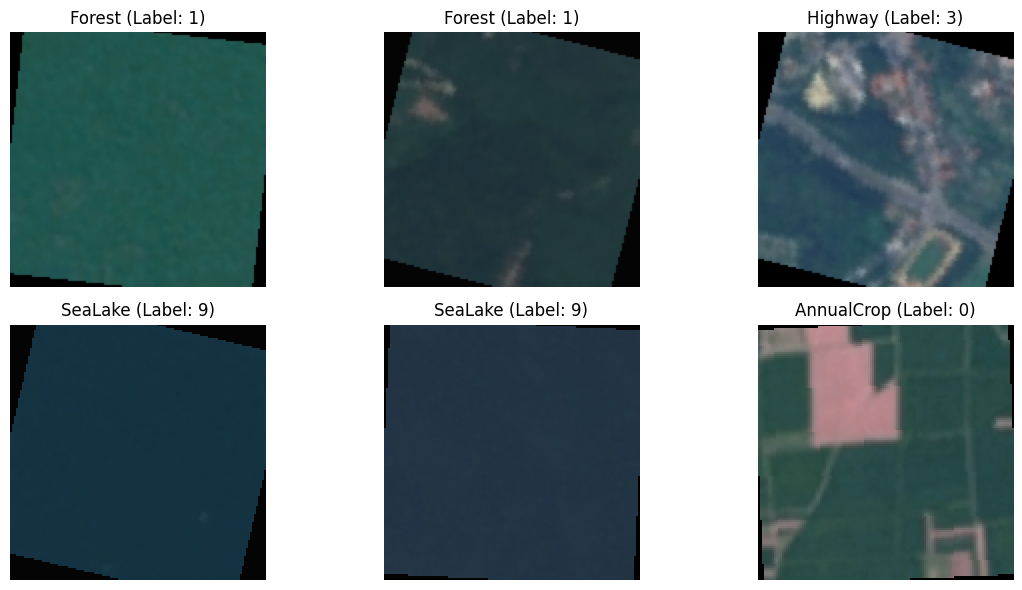

In [8]:

# DATA LOADING CONFIGURATION


batch_size = 32
num_workers = 0  # Set to 0 for Jupyter notebooks to avoid multiprocessing issues

print("Loading dataset...")
print(f"📁 Data root: {data_root}")
print(f"📄 Train CSV: {os.path.join(data_root, 'train.csv')}")
print(f"📄 Val CSV:    {os.path.join(data_root, 'validation.csv')}")
print(f"📄 Test CSV:   {os.path.join(data_root, 'test.csv')}")

train_loader, val_loader, test_loader, class_names = create_dataloaders(
    data_root=data_root,
    batch_size=batch_size,
    num_workers=num_workers
)

print(f"\n✅ Dataset loaded successfully!")
print(f"   Number of classes: {len(class_names)}")
print(f"   Classes: {class_names}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# Fetch one batch
sample_batch = next(iter(train_loader))
images, labels, class_names_batch = sample_batch
print(f"\n   Sample batch shape: {images.shape}")
print(f"   Sample labels: {labels[:5].tolist()}")
print(f"   Sample class names: {class_names_batch[:5]}")


# SHOW SAMPLE IMAGES

import matplotlib.pyplot as plt
import torchvision.transforms as T

# Denormalization 
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def show_images(images, labels, names, num=6):
    """Display a few sample images with labels."""
    plt.figure(figsize=(12, 6))
    for i in range(min(num, len(images))):
        img = images[i]

        # De-normalize for display
        img = inv_normalize(img)
        img = img.permute(1, 2, 0).numpy()
        img = img.clip(0, 1)  # safety clip

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{names[i]} (Label: {labels[i].item()})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\n📸 Showing sample images from train loader...")
show_images(images, labels, class_names_batch)


---

## 5. Model 1: Vision Transformer (ViT) - Pretrained



In [14]:
# ============================================================================
# CREATE ViT MODEL (PRETRAINED)
# ============================================================================

print("Creating ViT-Base model with pretrained weights...")
print("Model: vit_base_patch16_224")
print("Pretrained on: ImageNet-21k → ImageNet-1k")

# Load pretrained ViT from timm
vit_model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,  # Use pretrained weights!
    num_classes=len(class_names),
    img_size=128  # Our image size
)

# Count parameters
total_params, trainable_params = count_parameters(vit_model)
print(f"\n✅ ViT Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['ViT'] = {
    'model': vit_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating ViT-Base model with pretrained weights...
Model: vit_base_patch16_224
Pretrained on: ImageNet-21k → ImageNet-1k

✅ ViT Model Created!
   Total parameters: 85,704,970
   Trainable parameters: 85,704,970
   Model type: PRETRAINED (Transfer Learning)


In [15]:
# ============================================================================
# TRAIN ViT MODEL
# ============================================================================

# Train ViT with fewer epochs for CPU (can increase if needed)
vit_model, vit_history, vit_test_metrics = train_model(
    model=vit_model,
    model_name='ViT',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=10,  # Reduced for CPU training
    learning_rate=0.0001,  # Lower LR for fine-tuning pretrained model
    early_stopping_patience=5
)

# Store results
all_model_results['ViT']['history'] = vit_history
all_model_results['ViT']['test_metrics'] = vit_test_metrics
all_model_results['ViT']['test_accuracy'] = vit_test_metrics['accuracy']



Training ViT

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:08<00:00,  2.45it/s, loss=0.187] 



Train Loss: 0.4099 | Train Acc: 0.8605 | Train F1: 0.8579
Val Loss: 0.2263 | Val Acc: 0.9246 | Val F1: 0.9250
💾 Best model saved! (Val Loss: 0.2263)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:07<00:00,  2.52it/s, loss=0.0893]



Train Loss: 0.2037 | Train Acc: 0.9291 | Train F1: 0.9282
Val Loss: 0.1322 | Val Acc: 0.9572 | Val F1: 0.9560
💾 Best model saved! (Val Loss: 0.1322)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.1356 | Train Acc: 0.9534 | Train F1: 0.9527
Val Loss: 0.1874 | Val Acc: 0.9313 | Val F1: 0.9296

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:08<00:00,  2.46it/s, loss=0.00915]



Train Loss: 0.1329 | Train Acc: 0.9561 | Train F1: 0.9551
Val Loss: 0.1092 | Val Acc: 0.9622 | Val F1: 0.9612

Training completed in 135.57 minutes

Evaluating ViT on test set...


Validation: 100%|██████████| 85/85 [00:34<00:00,  2.47it/s, loss=0.00761]


📊 Test Results for ViT:
   Loss: 0.0928
   Accuracy: 0.9700
   F1-Macro: 0.9688
   F1-Weighted: 0.9700
   Balanced Accuracy: 0.9691


---

## 6. Model 2: ResNet-18 - Pretrained




In [16]:
# ============================================================================
# CREATE RESNET-18 MODEL (PRETRAINED)
# ============================================================================

print("Creating ResNet-18 model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained ResNet-18
resnet_model = models.resnet18(pretrained=True)

# Replace the final classification layer
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, len(class_names))

# Count parameters
total_params, trainable_params = count_parameters(resnet_model)
print(f"\n✅ ResNet-18 Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['ResNet-18'] = {
    'model': resnet_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/shoumik/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


Creating ResNet-18 model with pretrained weights...
Pretrained on: ImageNet-1k


100%|██████████| 44.7M/44.7M [00:02<00:00, 18.0MB/s]


✅ ResNet-18 Model Created!
   Total parameters: 11,181,642
   Trainable parameters: 11,181,642
   Model type: PRETRAINED (Transfer Learning)


In [17]:
# ============================================================================
# TRAIN RESNET-18 MODEL
# ============================================================================

resnet_model, resnet_history, resnet_test_metrics = train_model(
    model=resnet_model,
    model_name='ResNet-18',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=10,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
all_model_results['ResNet-18']['history'] = resnet_history
all_model_results['ResNet-18']['test_metrics'] = resnet_test_metrics
all_model_results['ResNet-18']['test_accuracy'] = resnet_test_metrics['accuracy']



Training ResNet-18

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:29<00:00,  1.89it/s, loss=0.0262]



Train Loss: 0.3602 | Train Acc: 0.8807 | Train F1: 0.8783
Val Loss: 0.1405 | Val Acc: 0.9528 | Val F1: 0.9521
💾 Best model saved! (Val Loss: 0.1405)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:28<00:00,  1.90it/s, loss=0.0278] 



Train Loss: 0.2058 | Train Acc: 0.9321 | Train F1: 0.9308
Val Loss: 0.1059 | Val Acc: 0.9656 | Val F1: 0.9642
💾 Best model saved! (Val Loss: 0.1059)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.1062 | Train Acc: 0.9633 | Train F1: 0.9626
Val Loss: 0.0794 | Val Acc: 0.9733 | Val F1: 0.9724

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:28<00:00,  1.92it/s, loss=0.0182] 



Train Loss: 0.0948 | Train Acc: 0.9676 | Train F1: 0.9670
Val Loss: 0.0816 | Val Acc: 0.9717 | Val F1: 0.9710

Training completed in 120.58 minutes

Evaluating ResNet-18 on test set...


Validation: 100%|██████████| 85/85 [00:42<00:00,  1.99it/s, loss=0.000302]


📊 Test Results for ResNet-18:
   Loss: 0.0650
   Accuracy: 0.9793
   F1-Macro: 0.9786
   F1-Weighted: 0.9793
   Balanced Accuracy: 0.9790


---

## 7. Model 3: EfficientNet-B0 - Pretrained





In [18]:
# ============================================================================
# CREATE EFFICIENTNET-B0 MODEL (PRETRAINED)
# ============================================================================

print("Creating EfficientNet-B0 model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained EfficientNet-B0
efficientnet_model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=len(class_names)
)

# Count parameters
total_params, trainable_params = count_parameters(efficientnet_model)
print(f"\n✅ EfficientNet-B0 Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['EfficientNet-B0'] = {
    'model': efficientnet_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating EfficientNet-B0 model with pretrained weights...
Pretrained on: ImageNet-1k

✅ EfficientNet-B0 Model Created!
   Total parameters: 4,020,358
   Trainable parameters: 4,020,358
   Model type: PRETRAINED (Transfer Learning)


In [35]:
# ============================================================================
# TRAIN EFFICIENTNET-B0 MODEL
# ============================================================================

efficientnet_model, efficientnet_history, efficientnet_test_metrics = train_model(
    model=efficientnet_model,
    model_name='EfficientNet-B0',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=2,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
all_model_results['EfficientNet-B0']['history'] = efficientnet_history
all_model_results['EfficientNet-B0']['test_metrics'] = efficientnet_test_metrics
all_model_results['EfficientNet-B0']['test_accuracy'] = efficientnet_test_metrics['accuracy']



Training EfficientNet-B0

Epoch 1/2
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [02:41<00:00,  1.04it/s, loss=0.133] 



Train Loss: 0.6724 | Train Acc: 0.7979 | Train F1: 0.7936
Val Loss: 0.2321 | Val Acc: 0.9219 | Val F1: 0.9208
💾 Best model saved! (Val Loss: 0.2321)

Epoch 2/2
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [02:42<00:00,  1.04it/s, loss=0.062] 



Train Loss: 0.2779 | Train Acc: 0.9060 | Train F1: 0.9042
Val Loss: 0.1482 | Val Acc: 0.9465 | Val F1: 0.9457
💾 Best model saved! (Val Loss: 0.1482)

Training completed in 86.29 minutes

Evaluating EfficientNet-B0 on test set...


Validation: 100%|██████████| 85/85 [01:20<00:00,  1.05it/s, loss=0.00894]


📊 Test Results for EfficientNet-B0:
   Loss: 0.1306
   Accuracy: 0.9581
   F1-Macro: 0.9571
   F1-Weighted: 0.9585
   Balanced Accuracy: 0.9581


---

## 8. Model 4: DenseNet-121 - Pretrained



In [29]:
# ============================================================================
# CREATE DENSENET-121 MODEL (PRETRAINED)
# ============================================================================

print("Creating DenseNet-121 model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained DenseNet-121
densenet_model = models.densenet121(pretrained=True)

# Replace the final classification layer
num_features = densenet_model.classifier.in_features
densenet_model.classifier = nn.Linear(num_features, len(class_names))

# Count parameters
total_params, trainable_params = count_parameters(densenet_model)
print(f"\n✅ DenseNet-121 Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['DenseNet-121'] = {
    'model': densenet_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating DenseNet-121 model with pretrained weights...
Pretrained on: ImageNet-1k

✅ DenseNet-121 Model Created!
   Total parameters: 6,964,106
   Trainable parameters: 6,964,106
   Model type: PRETRAINED (Transfer Learning)


In [30]:
# ============================================================================
# TRAIN DENSENET-121 MODEL
# ============================================================================

densenet_model, densenet_history, densenet_test_metrics = train_model(
    model=densenet_model,
    model_name='DenseNet-121',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=3,
    learning_rate=0.0001,
    early_stopping_patience=3
)

# Store results
all_model_results['DenseNet-121']['history'] = densenet_history
all_model_results['DenseNet-121']['test_metrics'] = densenet_test_metrics
all_model_results['DenseNet-121']['test_accuracy'] = densenet_test_metrics['accuracy']



Training DenseNet-121

Epoch 1/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [03:34<00:00,  1.27s/it, loss=0.0415]



Train Loss: 0.3466 | Train Acc: 0.8918 | Train F1: 0.8899
Val Loss: 0.1147 | Val Acc: 0.9656 | Val F1: 0.9646
💾 Best model saved! (Val Loss: 0.1147)

Epoch 2/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [03:37<00:00,  1.29s/it, loss=0.0112] 



Train Loss: 0.1606 | Train Acc: 0.9475 | Train F1: 0.9464
Val Loss: 0.0862 | Val Acc: 0.9681 | Val F1: 0.9670
💾 Best model saved! (Val Loss: 0.0862)

Epoch 3/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [03:37<00:00,  1.28s/it, loss=0.00358]



Train Loss: 0.1251 | Train Acc: 0.9583 | Train F1: 0.9575
Val Loss: 0.0717 | Val Acc: 0.9772 | Val F1: 0.9764
💾 Best model saved! (Val Loss: 0.0717)

Training completed in 94.27 minutes

Evaluating DenseNet-121 on test set...


Validation: 100%|██████████| 85/85 [01:48<00:00,  1.28s/it, loss=0.00816]


📊 Test Results for DenseNet-121:
   Loss: 0.0654
   Accuracy: 0.9819
   F1-Macro: 0.9815
   F1-Weighted: 0.9819
   Balanced Accuracy: 0.9803


---

## 9. Model 5: Simple CNN - From Scratch


In [31]:
# ============================================================================
# CREATE SIMPLE CNN MODEL (FROM SCRATCH)
# ============================================================================

class SimpleCNN(nn.Module):
    """Simple CNN architecture for LULC classification"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        # After 3 pooling operations: 128/2/2/2 = 16, so 16*16*128 = 32768
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Conv block 1
        x = self.pool(torch.relu(self.conv1(x)))
        
        # Conv block 2
        x = self.pool(torch.relu(self.conv2(x)))
        
        # Conv block 3
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(-1, 128 * 16 * 16)
        
        # Fully connected layers
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

print("Creating Simple CNN model (from scratch)...")
simple_cnn_model = SimpleCNN(num_classes=len(class_names))

# Count parameters
total_params, trainable_params = count_parameters(simple_cnn_model)
print(f"\n✅ Simple CNN Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: FROM SCRATCH (no pretrained weights)")

# Store model info
all_model_results['Simple CNN'] = {
    'model': simple_cnn_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating Simple CNN model (from scratch)...

✅ Simple CNN Model Created!
   Total parameters: 16,876,106
   Trainable parameters: 16,876,106
   Model type: FROM SCRATCH (no pretrained weights)


In [32]:
# ============================================================================
# TRAIN SIMPLE CNN MODEL
# ============================================================================

# Use higher learning rate for from-scratch training
simple_cnn_model, simple_cnn_history, simple_cnn_test_metrics = train_model(
    model=simple_cnn_model,
    model_name='Simple CNN',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=15,  # More epochs for from-scratch training
    learning_rate=0.001,  # Higher LR for from-scratch
    early_stopping_patience=3
)

# Store results
all_model_results['Simple CNN']['history'] = simple_cnn_history
all_model_results['Simple CNN']['test_metrics'] = simple_cnn_test_metrics
all_model_results['Simple CNN']['test_accuracy'] = simple_cnn_test_metrics['accuracy']



Training Simple CNN

Epoch 1/15
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [00:24<00:00,  6.96it/s, loss=0.836]



Train Loss: 1.3870 | Train Acc: 0.4806 | Train F1: 0.4603
Val Loss: 0.8832 | Val Acc: 0.6417 | Val F1: 0.6171
💾 Best model saved! (Val Loss: 0.8832)

Epoch 2/15
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [00:24<00:00,  6.95it/s, loss=0.907]



Train Loss: 1.0159 | Train Acc: 0.6240 | Train F1: 0.6071
Val Loss: 0.7926 | Val Acc: 0.6939 | Val F1: 0.6790
💾 Best model saved! (Val Loss: 0.7926)

Epoch 3/15
------------------------------------------------------------


...


Train Loss: 0.4304 | Train Acc: 0.8524 | Train F1: 0.8475
Val Loss: 0.3164 | Val Acc: 0.8941 | Val F1: 0.8901
💾 Best model saved! (Val Loss: 0.3164)

Epoch 15/15
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [00:26<00:00,  6.28it/s, loss=0.196]



Train Loss: 0.4065 | Train Acc: 0.8601 | Train F1: 0.8554
Val Loss: 0.3489 | Val Acc: 0.8815 | Val F1: 0.8768

Training completed in 58.73 minutes

Evaluating Simple CNN on test set...


Validation: 100%|██████████| 85/85 [00:13<00:00,  6.22it/s, loss=0.222]


📊 Test Results for Simple CNN:
   Loss: 0.3127
   Accuracy: 0.8885
   F1-Macro: 0.8843
   F1-Weighted: 0.8875
   Balanced Accuracy: 0.8858


---

## 10. Model 6: Swin Transformer Tiny - Pretrained



In [33]:
# ============================================================================
# CREATE SWIN TRANSFORMER TINY MODEL (PRETRAINED)
# ============================================================================

print("Creating Swin Transformer Tiny model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained Swin Transformer Tiny
swin_model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=len(class_names),
    img_size=128
)

# Count parameters
total_params, trainable_params = count_parameters(swin_model)
print(f"\n✅ Swin Transformer Tiny Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['Swin Transformer'] = {
    'model': swin_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating Swin Transformer Tiny model with pretrained weights...
Pretrained on: ImageNet-1k

✅ Swin Transformer Tiny Model Created!
   Total parameters: 27,521,284
   Trainable parameters: 27,521,284
   Model type: PRETRAINED (Transfer Learning)


/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)


In [34]:
# ============================================================================
# TRAIN SWIN TRANSFORMER MODEL
# ============================================================================

swin_model, swin_history, swin_test_metrics = train_model(
    model=swin_model,
    model_name='Swin Transformer',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=3,
    learning_rate=0.0001,
    early_stopping_patience=3
)

# Store results
all_model_results['Swin Transformer']['history'] = swin_history
all_model_results['Swin Transformer']['test_metrics'] = swin_test_metrics
all_model_results['Swin Transformer']['test_accuracy'] = swin_test_metrics['accuracy']



Training Swin Transformer

Epoch 1/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:00<00:00,  2.81it/s, loss=0.0106]



Train Loss: 0.2509 | Train Acc: 0.9181 | Train F1: 0.9164
Val Loss: 0.1040 | Val Acc: 0.9654 | Val F1: 0.9639
💾 Best model saved! (Val Loss: 0.1040)

Epoch 2/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:02<00:00,  2.71it/s, loss=0.0309] 



Train Loss: 0.1255 | Train Acc: 0.9589 | Train F1: 0.9581
Val Loss: 0.1302 | Val Acc: 0.9550 | Val F1: 0.9537

Epoch 3/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:03<00:00,  2.67it/s, loss=0.00201]



Train Loss: 0.1006 | Train Acc: 0.9673 | Train F1: 0.9665
Val Loss: 0.0629 | Val Acc: 0.9781 | Val F1: 0.9776
💾 Best model saved! (Val Loss: 0.0629)

Training completed in 34.90 minutes

Evaluating Swin Transformer on test set...


Validation: 100%|██████████| 85/85 [00:32<00:00,  2.64it/s, loss=0.0007] 


📊 Test Results for Swin Transformer:
   Loss: 0.0525
   Accuracy: 0.9826
   F1-Macro: 0.9819
   F1-Weighted: 0.9826
   Balanced Accuracy: 0.9820


---

## 11. Model Comparison & Results

### 📊 **Compare All Models**

Let's compare the performance of all models and see which one performs best!


MODEL COMPARISON - TEST SET RESULTS

📊 Test Set Performance (sorted by Accuracy):
           Model  Accuracy  F1-Macro  F1-Weighted  Balanced Accuracy  Total Params  Trainable Params
Swin Transformer  0.982593  0.981914     0.982632           0.982033      27521284          27521284
    DenseNet-121  0.981852  0.981509     0.981859           0.980333       6964106           6964106
       ResNet-18  0.979259  0.978609     0.979276           0.979033      11181642          11181642
             ViT  0.970000  0.968809     0.970047           0.969067      85704970          85704970
 EfficientNet-B0  0.958148  0.957091     0.958467           0.958133       4020358           4020358
      Simple CNN  0.888519  0.884329     0.887547           0.885800      16876106          16876106


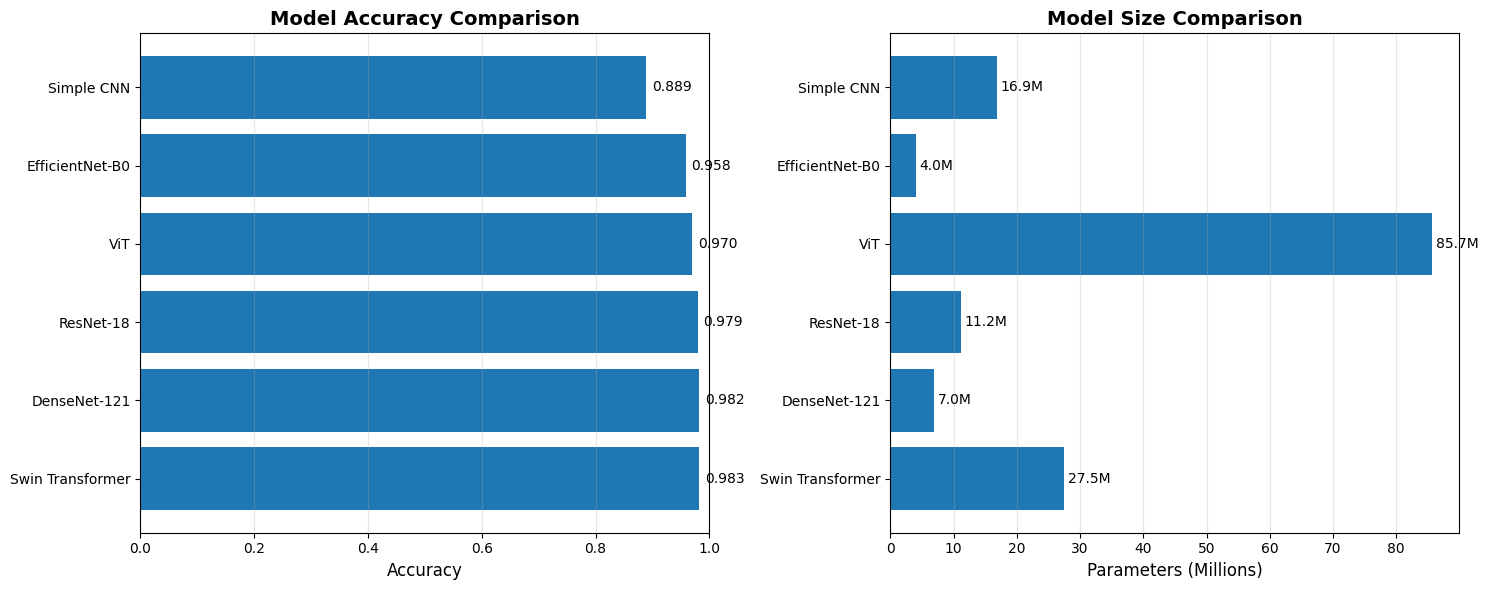


🏆 Best Model: Swin Transformer
   Accuracy: 0.9826
   F1-Macro: 0.9819


In [36]:
# ============================================================================
# COMPARE ALL MODELS
# ============================================================================

print("="*80)
print("MODEL COMPARISON - TEST SET RESULTS")
print("="*80)

# Create comparison dataframe
comparison_data = []
for model_name, results in all_model_results.items():
    if 'test_metrics' in results:
        comparison_data.append({
            'Model': model_name,
            'Accuracy': results['test_metrics']['accuracy'],
            'F1-Macro': results['test_metrics']['f1_macro'],
            'F1-Weighted': results['test_metrics']['f1_weighted'],
            'Balanced Accuracy': results['test_metrics']['balanced_accuracy'],
            'Total Params': results['total_params'],
            'Trainable Params': results['trainable_params']
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

# Display results
print("\n📊 Test Set Performance (sorted by Accuracy):")
print(comparison_df.to_string(index=False))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'])
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# Parameter count comparison
axes[1].barh(comparison_df['Model'], comparison_df['Total Params'] / 1e6)
axes[1].set_xlabel('Parameters (Millions)', fontsize=12)
axes[1].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Total Params'] / 1e6):
    axes[1].text(v + 0.5, i, f'{v:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Find best model
best_model = comparison_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   F1-Macro: {best_model['F1-Macro']:.4f}")


### 📄 **Comparison with Paper Results**



In [41]:
# ==============================================================
# PAPER vs OUR MODEL COMPARISON (EuroSAT - Test Accuracy)
# ==============================================================

import pandas as pd

# --- Paper accuracy values (Table-4, EuroSAT) ---
paper_results = {
    "Swin Transformer": 0.9828,   # SwinT-Small
    "ViT": 0.9870,                # ViT-Base
    "DenseNet": 0.9769,           # DenseNet-161 
    "CNN": 0.9422,    
    "ResNet-50": 0.9657               
}

# --- Your accuracy values from test metrics (screenshot) ---
our_results = {
    "Swin Transformer": all_model_results["Swin Transformer"]["test_metrics"]["accuracy"],
    "ViT": all_model_results["ViT"]["test_metrics"]["accuracy"],
    "DenseNet": all_model_results["DenseNet-121"]["test_metrics"]["accuracy"],
    "CNN": all_model_results["Simple CNN"]["test_metrics"]["accuracy"],
     "ResNet-18": all_model_results["ResNet-18"]["test_metrics"]["accuracy"]

}

# Create comparison DataFrame
compare_df = pd.DataFrame({
    "Model": list(paper_results.keys()),
    "Paper Accuracy": [paper_results[m] for m in paper_results],
    "Our Accuracy": [our_results[m] for m in our_results]
})

# Calculate difference (Our − Paper)
compare_df["Difference"] = compare_df["Our Accuracy"] - compare_df["Paper Accuracy"]

# Sort by Paper Accuracy (optional)
compare_df = compare_df.sort_values(by="Paper Accuracy", ascending=False).reset_index(drop=True)

print("\n📊 Paper vs Our Model Comparison (EuroSAT Test Accuracy)")
print(compare_df.to_string(index=False))


📊 Paper vs Our Model Comparison (EuroSAT Test Accuracy)
           Model  Paper Accuracy  Our Accuracy  Difference
             ViT          0.9870      0.970000   -0.017000
Swin Transformer          0.9828      0.982593   -0.000207
        DenseNet          0.9769      0.981852    0.004952
       ResNet-50          0.9657      0.979259    0.013559
             CNN          0.9422      0.888519   -0.053681


# =============================================================================
# UC MERCED LAND USE DATASET EXPERIMENT (INDEPENDENT FROM EUROSAT)
# =============================================================================

This section contains a completely independent experiment on the UC Merced Land Use Dataset.
**DO NOT modify or rerun any previous EuroSAT code above.**

**Dataset Details:**
- **Dataset name**: UC Merced Land Use Dataset
- **Classes**: 21
- **Images per class**: 100
- **Image size**: 256 × 256 (will be resized to 128×128 for consistency)
- **Total images**: 2,100



In [10]:
# ============================================================================
# UC MERCED DATASET LOADER
# ============================================================================

class UCMercedDataset(Dataset):
    """UC Merced Land Use Dataset Loader"""
    def __init__(self, data_root, transform=None, split='train', train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
        self.data_root = data_root
        self.images_dir = os.path.join(data_root, 'Images')
        self.transform = transform
        
        # Get all class folders
        self.class_names = sorted([d for d in os.listdir(self.images_dir) 
                                   if os.path.isdir(os.path.join(self.images_dir, d))])
        
        # Create label map
        self.label_map = {class_name: idx for idx, class_name in enumerate(self.class_names)}
        
        # Collect all image paths with labels
        self.samples = []
        for class_name in self.class_names:
            class_dir = os.path.join(self.images_dir, class_name)
            label = self.label_map[class_name]
            
            # Get all images in this class folder
            image_files = sorted([f for f in os.listdir(class_dir) 
                                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))])
            
            for img_file in image_files:
                img_path = os.path.join(class_dir, img_file)
                self.samples.append((img_path, label, class_name))
        
        # Split dataset
        np.random.seed(seed)
        np.random.shuffle(self.samples)
        
        total_samples = len(self.samples)
        train_end = int(total_samples * train_ratio)
        val_end = train_end + int(total_samples * val_ratio)
        
        if split == 'train':
            self.samples = self.samples[:train_end]
        elif split == 'val':
            self.samples = self.samples[train_end:val_end]
        elif split == 'test':
            self.samples = self.samples[val_end:]
        else:
            raise ValueError(f"Invalid split: {split}. Must be 'train', 'val', or 'test'")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label, class_name = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label, class_name
    
    def get_class_names(self):
        """Return list of class names in order"""
        return self.class_names


def create_ucmerced_dataloaders(data_root, batch_size=32, num_workers=0, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """Create train/val/test dataloaders for UC Merced dataset"""
    
    # Get transforms (same as EuroSAT)
    train_transform = get_preprocessing_transforms(augment=True)
    val_transform = get_preprocessing_transforms(augment=False)
    test_transform = get_preprocessing_transforms(augment=False)
    
    # Create datasets
    train_dataset = UCMercedDataset(data_root, transform=train_transform, split='train', 
                                    train_ratio=train_ratio, val_ratio=val_ratio, test_ratio=test_ratio)
    val_dataset = UCMercedDataset(data_root, transform=val_transform, split='val',
                                  train_ratio=train_ratio, val_ratio=val_ratio, test_ratio=test_ratio)
    test_dataset = UCMercedDataset(data_root, transform=test_transform, split='test',
                                   train_ratio=train_ratio, val_ratio=val_ratio, test_ratio=test_ratio)
    
    # Get class names
    class_names = train_dataset.get_class_names()
    
    # Create dataloaders
    train_loader_ucm = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)
    )
    
    val_loader_ucm = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)
    )
    
    test_loader_ucm = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)
    )
    
    return train_loader_ucm, val_loader_ucm, test_loader_ucm, class_names

print("✅ UC Merced dataset loader defined")



✅ UC Merced dataset loader defined


Loading UC Merced dataset...
📁 Data root: /Users/shoumik/Downloads/UCMerced_LandUse
📁 Images directory: /Users/shoumik/Downloads/UCMerced_LandUse/Images

✅ UC Merced dataset loaded successfully!
   Number of classes: 21
   Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
   Train batches: 46
   Val batches:   10
   Test batches:  10

   Sample batch shape: torch.Size([32, 3, 128, 128])
   Sample labels: [0, 11, 13, 17, 20]
   Sample class names: ('agricultural', 'intersection', 'mobilehomepark', 'runway', 'tenniscourt')

📸 Showing sample images from UC Merced train loader...


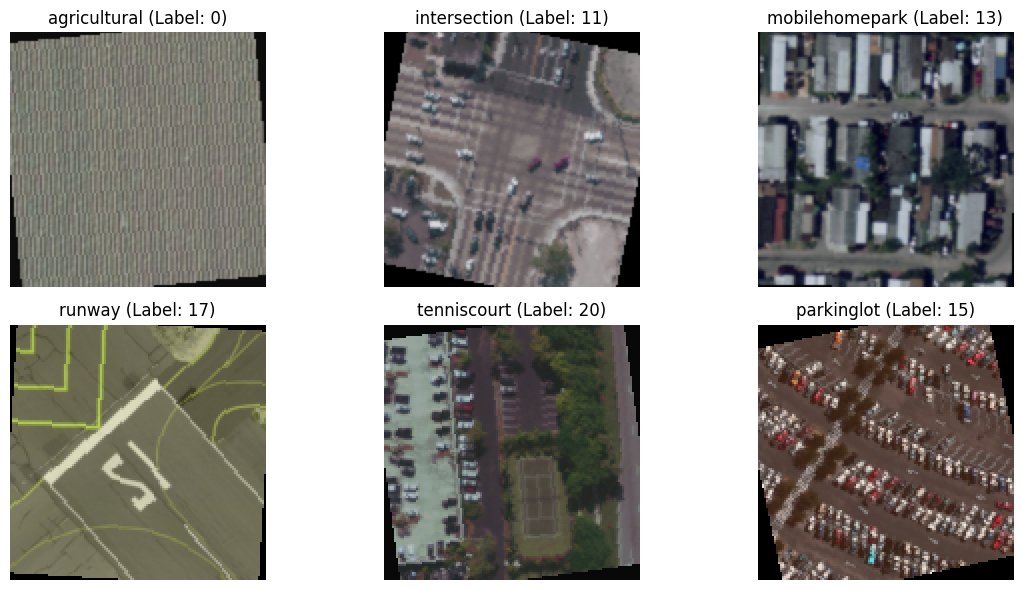

In [11]:
# ============================================================================
# LOAD UC MERCED DATASET
# ============================================================================

# UC Merced dataset path
ucmerced_data_root = '/Users/shoumik/Downloads/UCMerced_LandUse'

print("Loading UC Merced dataset...")
print(f"📁 Data root: {ucmerced_data_root}")
print(f"📁 Images directory: {os.path.join(ucmerced_data_root, 'Images')}")

# Create dataloaders (70/15/15 split)
train_loader_ucm, val_loader_ucm, test_loader_ucm, class_names_ucm = create_ucmerced_dataloaders(
    data_root=ucmerced_data_root,
    batch_size=32,
    num_workers=0,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15
)

print(f"\n✅ UC Merced dataset loaded successfully!")
print(f"   Number of classes: {len(class_names_ucm)}")
print(f"   Classes: {class_names_ucm}")
print(f"   Train batches: {len(train_loader_ucm)}")
print(f"   Val batches:   {len(val_loader_ucm)}")
print(f"   Test batches:  {len(test_loader_ucm)}")

# Fetch one batch
sample_batch_ucm = next(iter(train_loader_ucm))
images_ucm, labels_ucm, class_names_batch_ucm = sample_batch_ucm
print(f"\n   Sample batch shape: {images_ucm.shape}")
print(f"   Sample labels: {labels_ucm[:5].tolist()}")
print(f"   Sample class names: {class_names_batch_ucm[:5]}")

# Show sample images
print("\n📸 Showing sample images from UC Merced train loader...")
show_images(images_ucm, labels_ucm, class_names_batch_ucm)



## UC Merced Model Training

Training the same models used for EuroSAT on UC Merced dataset.



### Model 1: DenseNet-121 on UC Merced



In [13]:
# ============================================================================
# CREATE DENSENET-121 MODEL FOR UC MERCED
# ============================================================================

print("Creating DenseNet-121 model for UC Merced...")
print("Pretrained on: ImageNet-1k")

# Load pretrained DenseNet-121
densenet_ucm_model = models.densenet121(pretrained=True)

# Replace the final classification layer (21 classes for UC Merced)
num_features = densenet_ucm_model.classifier.in_features
densenet_ucm_model.classifier = nn.Linear(num_features, len(class_names_ucm))

# Count parameters
total_params_ucm_densenet, trainable_params_ucm_densenet = count_parameters(densenet_ucm_model)
print(f"\n✅ DenseNet-121 Model Created for UC Merced!")
print(f"   Total parameters: {total_params_ucm_densenet:,}")
print(f"   Trainable parameters: {trainable_params_ucm_densenet:,}")
print(f"   Number of classes: {len(class_names_ucm)}")



Creating DenseNet-121 model for UC Merced...
Pretrained on: ImageNet-1k

✅ DenseNet-121 Model Created for UC Merced!
   Total parameters: 6,975,381
   Trainable parameters: 6,975,381
   Number of classes: 21


In [14]:
# ============================================================================
# TRAIN DENSENET-121 ON UC MERCED
# ============================================================================

densenet_ucm_model, densenet_ucm_history, densenet_ucm_test_metrics = train_model(
    model=densenet_ucm_model,
    model_name='DenseNet-121-UCM',
    train_loader=train_loader_ucm,
    val_loader=val_loader_ucm,
    test_loader=test_loader_ucm,
    num_epochs=10,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
ucmerced_results = {}
ucmerced_results['DenseNet-121'] = {
    'history': densenet_ucm_history,
    'test_metrics': densenet_ucm_test_metrics,
    'test_accuracy': densenet_ucm_test_metrics['accuracy']
}




Training DenseNet-121-UCM

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:21<00:00,  2.18s/it, loss=1.04]



Train Loss: 1.9897 | Train Acc: 0.5231 | Train F1: 0.5345
Val Loss: 1.0758 | Val Acc: 0.8286 | Val F1: 0.8185
💾 Best model saved! (Val Loss: 1.0758)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:18<00:00,  1.88s/it, loss=0.389]



Train Loss: 0.6114 | Train Acc: 0.9082 | Train F1: 0.9039
Val Loss: 0.4733 | Val Acc: 0.9079 | Val F1: 0.9131
💾 Best model saved! (Val Loss: 0.4733)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.0525 | Train Acc: 0.9912 | Train F1: 0.9909
Val Loss: 0.1405 | Val Acc: 0.9556 | Val F1: 0.9580
💾 Best model saved! (Val Loss: 0.1405)

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:13<00:00,  1.40s/it, loss=0.0461]



Train Loss: 0.0459 | Train Acc: 0.9884 | Train F1: 0.9882
Val Loss: 0.1149 | Val Acc: 0.9587 | Val F1: 0.9612
💾 Best model saved! (Val Loss: 0.1149)

Training completed in 27.92 minutes

Evaluating DenseNet-121-UCM on test set...


Validation: 100%|██████████| 10/10 [00:14<00:00,  1.40s/it, loss=0.0194]


📊 Test Results for DenseNet-121-UCM:
   Loss: 0.0960
   Accuracy: 0.9810
   F1-Macro: 0.9814
   F1-Weighted: 0.9812
   Balanced Accuracy: 0.9837



📊 DenseNet-121 UC Merced Detailed Metrics:
   Accuracy: 0.9810
   Precision: 0.9811
   Recall: 0.9837
   F1-Score: 0.9814


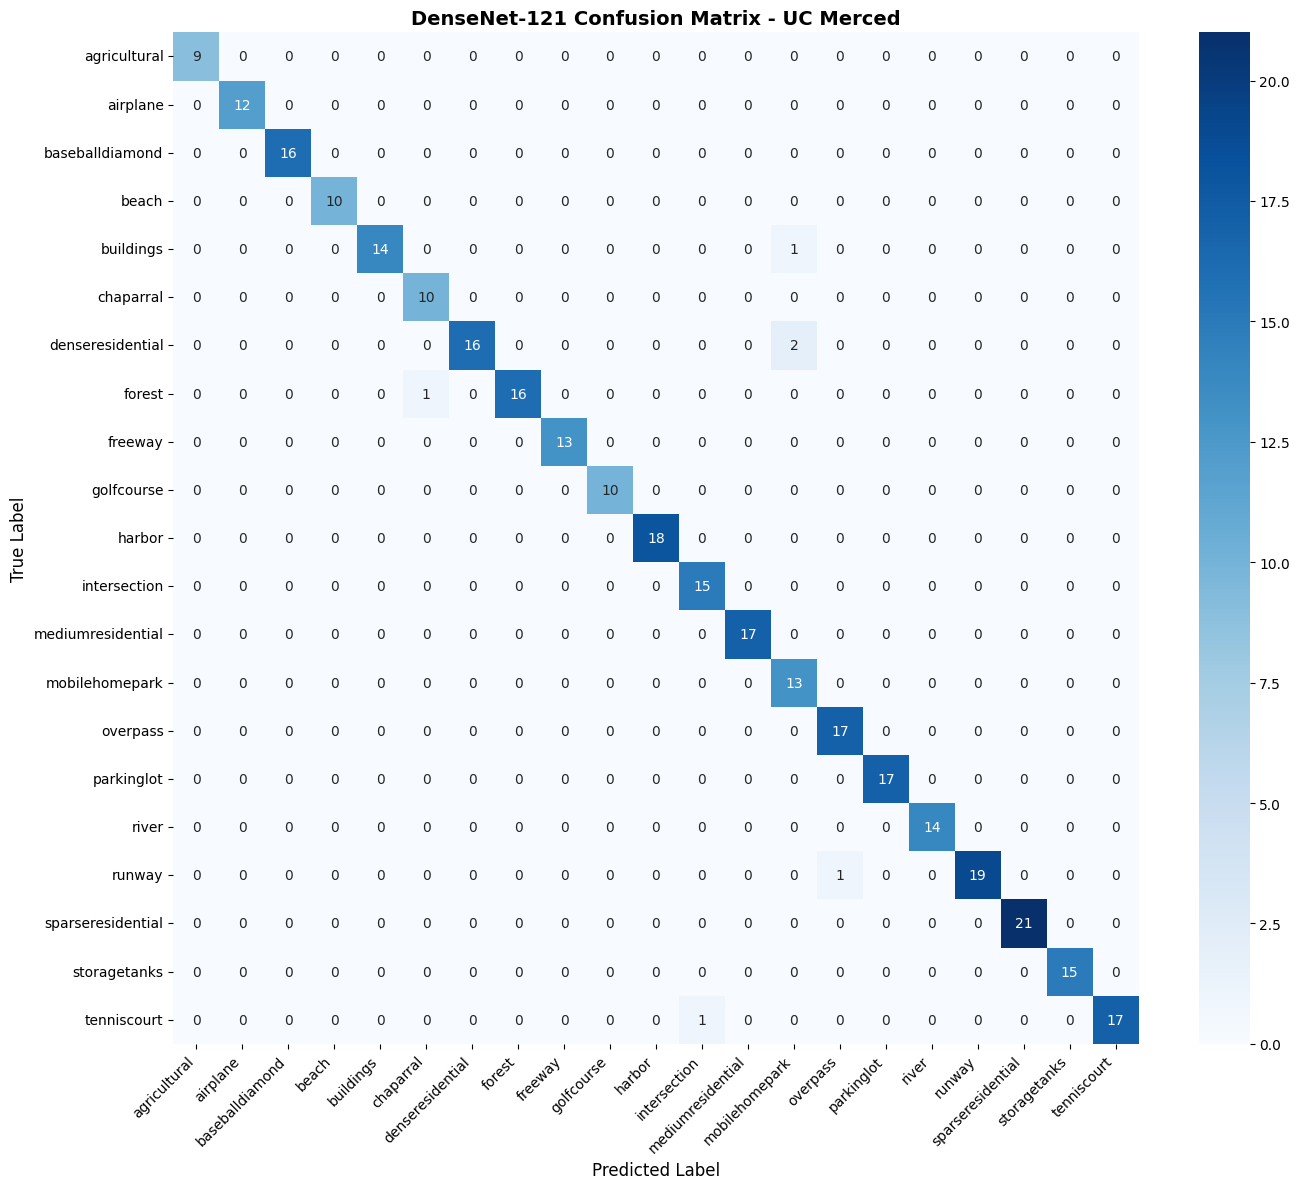

In [15]:
# ============================================================================
# EVALUATE DENSENET-121 ON UC MERCED - DETAILED METRICS
# ============================================================================

# Get predictions for confusion matrix
densenet_ucm_model.eval()
all_preds_ucm_densenet = []
all_labels_ucm_densenet = []

with torch.no_grad():
    for images, labels, _ in test_loader_ucm:
        images = images.to(device)
        labels = labels.to(device)
        outputs = densenet_ucm_model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds_ucm_densenet.extend(preds)
        all_labels_ucm_densenet.extend(labels.cpu().numpy())

all_preds_ucm_densenet = np.array(all_preds_ucm_densenet)
all_labels_ucm_densenet = np.array(all_labels_ucm_densenet)

# Calculate detailed metrics
from sklearn.metrics import precision_score, recall_score, classification_report

precision_ucm_densenet = precision_score(all_labels_ucm_densenet, all_preds_ucm_densenet, average='macro')
recall_ucm_densenet = recall_score(all_labels_ucm_densenet, all_preds_ucm_densenet, average='macro')
f1_ucm_densenet = densenet_ucm_test_metrics['f1_macro']

print(f"\n📊 DenseNet-121 UC Merced Detailed Metrics:")
print(f"   Accuracy: {densenet_ucm_test_metrics['accuracy']:.4f}")
print(f"   Precision: {precision_ucm_densenet:.4f}")
print(f"   Recall: {recall_ucm_densenet:.4f}")
print(f"   F1-Score: {f1_ucm_densenet:.4f}")

# Confusion Matrix
cm_ucm_densenet = confusion_matrix(all_labels_ucm_densenet, all_preds_ucm_densenet)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_ucm_densenet, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_ucm, yticklabels=class_names_ucm)
plt.title('DenseNet-121 Confusion Matrix - UC Merced', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Store detailed metrics
ucmerced_results['DenseNet-121']['precision'] = precision_ucm_densenet
ucmerced_results['DenseNet-121']['recall'] = recall_ucm_densenet
ucmerced_results['DenseNet-121']['f1'] = f1_ucm_densenet
ucmerced_results['DenseNet-121']['confusion_matrix'] = cm_ucm_densenet



### Model 2: Vision Transformer (ViT) on UC Merced



In [16]:
# ============================================================================
# CREATE ViT MODEL FOR UC MERCED
# ============================================================================

print("Creating ViT-Base model for UC Merced...")
print("Model: vit_base_patch16_224")
print("Pretrained on: ImageNet-21k → ImageNet-1k")

# Load pretrained ViT from timm
vit_ucm_model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=len(class_names_ucm),
    img_size=128
)

# Count parameters
total_params_ucm_vit, trainable_params_ucm_vit = count_parameters(vit_ucm_model)
print(f"\n✅ ViT Model Created for UC Merced!")
print(f"   Total parameters: {total_params_ucm_vit:,}")
print(f"   Trainable parameters: {trainable_params_ucm_vit:,}")
print(f"   Number of classes: {len(class_names_ucm)}")



Creating ViT-Base model for UC Merced...
Model: vit_base_patch16_224
Pretrained on: ImageNet-21k → ImageNet-1k

✅ ViT Model Created for UC Merced!
   Total parameters: 85,713,429
   Trainable parameters: 85,713,429
   Number of classes: 21


In [17]:
# ============================================================================
# TRAIN ViT ON UC MERCED
# ============================================================================

vit_ucm_model, vit_ucm_history, vit_ucm_test_metrics = train_model(
    model=vit_ucm_model,
    model_name='ViT-UCM',
    train_loader=train_loader_ucm,
    val_loader=val_loader_ucm,
    test_loader=test_loader_ucm,
    num_epochs=10,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
ucmerced_results['ViT'] = {
    'history': vit_ucm_history,
    'test_metrics': vit_ucm_test_metrics,
    'test_accuracy': vit_ucm_test_metrics['accuracy']
}




Training ViT-UCM

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:04<00:00,  2.27it/s, loss=0.748]



Train Loss: 1.2268 | Train Acc: 0.6320 | Train F1: 0.6254
Val Loss: 0.4754 | Val Acc: 0.8476 | Val F1: 0.8328
💾 Best model saved! (Val Loss: 0.4754)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:04<00:00,  2.20it/s, loss=0.219]



Train Loss: 0.2578 | Train Acc: 0.9184 | Train F1: 0.9168
Val Loss: 0.2310 | Val Acc: 0.9397 | Val F1: 0.9424
💾 Best model saved! (Val Loss: 0.2310)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.0885 | Train Acc: 0.9714 | Train F1: 0.9702
Val Loss: 0.1269 | Val Acc: 0.9651 | Val F1: 0.9655
💾 Best model saved! (Val Loss: 0.1269)

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:04<00:00,  2.25it/s, loss=0.441] 



Train Loss: 0.0374 | Train Acc: 0.9871 | Train F1: 0.9865
Val Loss: 0.2744 | Val Acc: 0.9238 | Val F1: 0.9281

Training completed in 10.88 minutes

Evaluating ViT-UCM on test set...


Validation: 100%|██████████| 10/10 [00:04<00:00,  2.26it/s, loss=0.142]


📊 Test Results for ViT-UCM:
   Loss: 0.1785
   Accuracy: 0.9429
   F1-Macro: 0.9452
   F1-Weighted: 0.9425
   Balanced Accuracy: 0.9488



📊 ViT UC Merced Detailed Metrics:
   Accuracy: 0.9429
   Precision: 0.9494
   Recall: 0.9488
   F1-Score: 0.9452


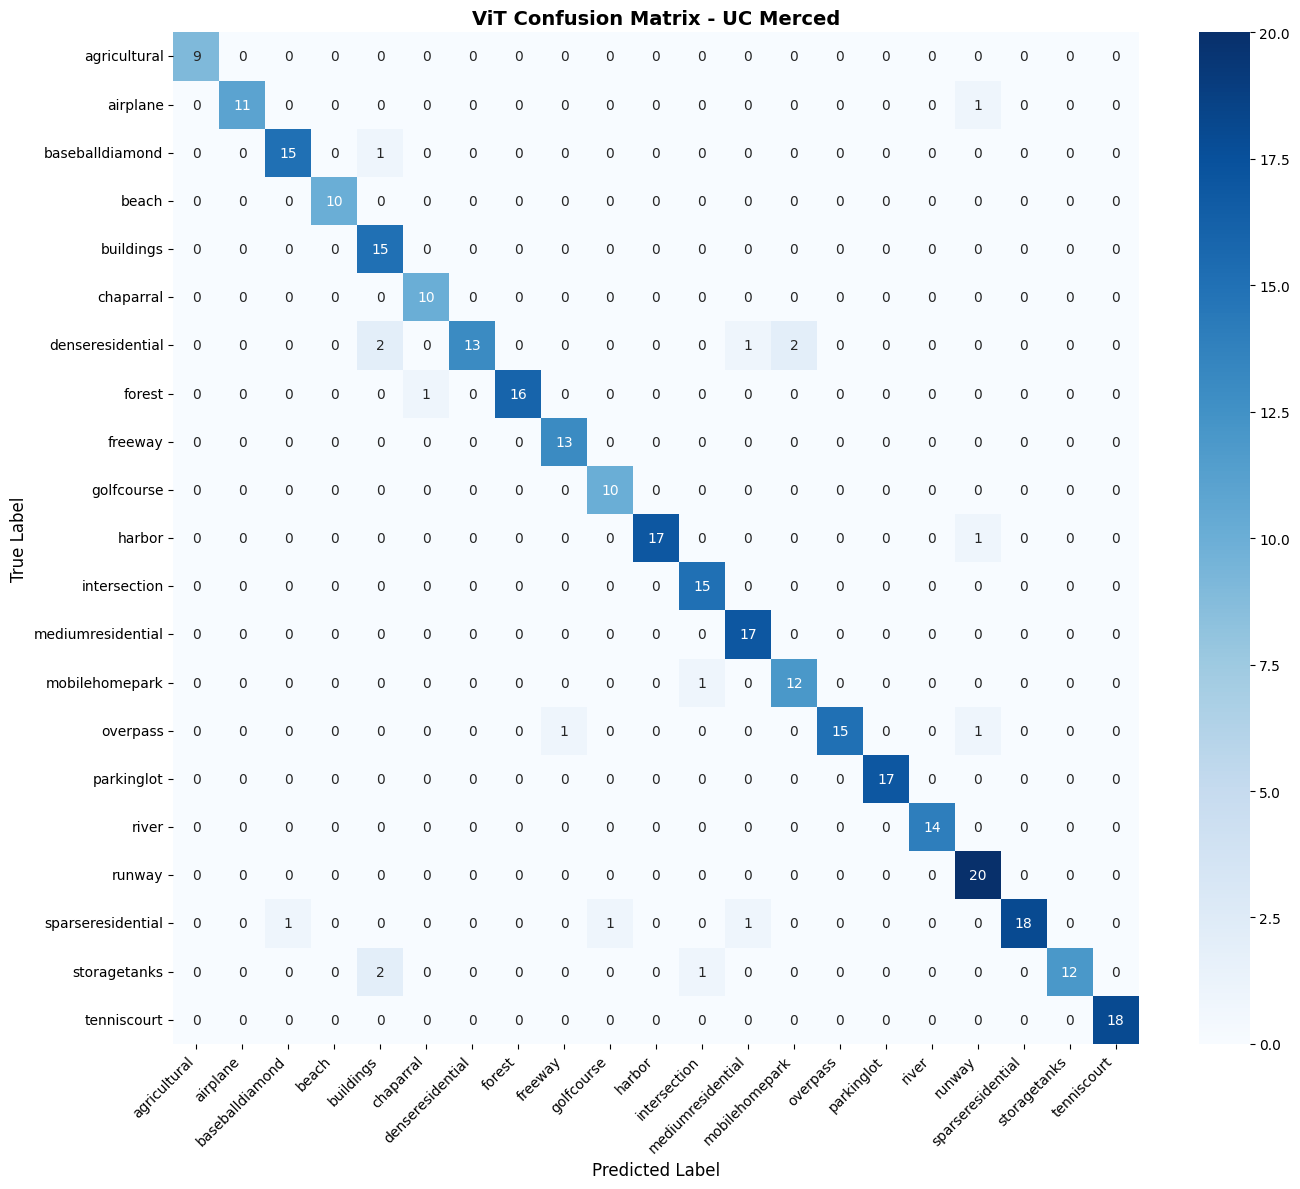

In [18]:
# ============================================================================
# EVALUATE ViT ON UC MERCED - DETAILED METRICS
# ============================================================================

# Get predictions for confusion matrix
vit_ucm_model.eval()
all_preds_ucm_vit = []
all_labels_ucm_vit = []

with torch.no_grad():
    for images, labels, _ in test_loader_ucm:
        images = images.to(device)
        labels = labels.to(device)
        outputs = vit_ucm_model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds_ucm_vit.extend(preds)
        all_labels_ucm_vit.extend(labels.cpu().numpy())

all_preds_ucm_vit = np.array(all_preds_ucm_vit)
all_labels_ucm_vit = np.array(all_labels_ucm_vit)

# Calculate detailed metrics
precision_ucm_vit = precision_score(all_labels_ucm_vit, all_preds_ucm_vit, average='macro')
recall_ucm_vit = recall_score(all_labels_ucm_vit, all_preds_ucm_vit, average='macro')
f1_ucm_vit = vit_ucm_test_metrics['f1_macro']

print(f"\n📊 ViT UC Merced Detailed Metrics:")
print(f"   Accuracy: {vit_ucm_test_metrics['accuracy']:.4f}")
print(f"   Precision: {precision_ucm_vit:.4f}")
print(f"   Recall: {recall_ucm_vit:.4f}")
print(f"   F1-Score: {f1_ucm_vit:.4f}")

# Confusion Matrix
cm_ucm_vit = confusion_matrix(all_labels_ucm_vit, all_preds_ucm_vit)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_ucm_vit, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_ucm, yticklabels=class_names_ucm)
plt.title('ViT Confusion Matrix - UC Merced', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Store detailed metrics
ucmerced_results['ViT']['precision'] = precision_ucm_vit
ucmerced_results['ViT']['recall'] = recall_ucm_vit
ucmerced_results['ViT']['f1'] = f1_ucm_vit
ucmerced_results['ViT']['confusion_matrix'] = cm_ucm_vit



### Model 3: Swin Transformer on UC Merced



In [19]:
# ============================================================================
# CREATE SWIN TRANSFORMER MODEL FOR UC MERCED
# ============================================================================

print("Creating Swin Transformer Tiny model for UC Merced...")
print("Pretrained on: ImageNet-1k")

# Load pretrained Swin Transformer Tiny
swin_ucm_model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=len(class_names_ucm),
    img_size=128
)

# Count parameters
total_params_ucm_swin, trainable_params_ucm_swin = count_parameters(swin_ucm_model)
print(f"\n✅ Swin Transformer Model Created for UC Merced!")
print(f"   Total parameters: {total_params_ucm_swin:,}")
print(f"   Trainable parameters: {trainable_params_ucm_swin:,}")
print(f"   Number of classes: {len(class_names_ucm)}")



Creating Swin Transformer Tiny model for UC Merced...
Pretrained on: ImageNet-1k

✅ Swin Transformer Model Created for UC Merced!
   Total parameters: 27,529,743
   Trainable parameters: 27,529,743
   Number of classes: 21


/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)


In [21]:
# ============================================================================
# TRAIN SWIN TRANSFORMER ON UC MERCED
# ============================================================================

swin_ucm_model, swin_ucm_history, swin_ucm_test_metrics = train_model(
    model=swin_ucm_model,
    model_name='Swin Transformer-UCM',
    train_loader=train_loader_ucm,
    val_loader=val_loader_ucm,
    test_loader=test_loader_ucm,
    num_epochs=10,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
ucmerced_results['Swin Transformer'] = {
    'history': swin_ucm_history,
    'test_metrics': swin_ucm_test_metrics,
    'test_accuracy': swin_ucm_test_metrics['accuracy']
}




Training Swin Transformer-UCM

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:04<00:00,  2.09it/s, loss=0.385]



Train Loss: 1.2918 | Train Acc: 0.6429 | Train F1: 0.6390
Val Loss: 0.3260 | Val Acc: 0.9016 | Val F1: 0.9042
💾 Best model saved! (Val Loss: 0.3260)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:03<00:00,  2.61it/s, loss=0.344]



Train Loss: 0.2254 | Train Acc: 0.9361 | Train F1: 0.9336
Val Loss: 0.2406 | Val Acc: 0.9175 | Val F1: 0.9174
💾 Best model saved! (Val Loss: 0.2406)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.0171 | Train Acc: 0.9946 | Train F1: 0.9944
Val Loss: 0.0831 | Val Acc: 0.9778 | Val F1: 0.9781

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:03<00:00,  2.56it/s, loss=0.0713] 



Train Loss: 0.0205 | Train Acc: 0.9959 | Train F1: 0.9957
Val Loss: 0.1219 | Val Acc: 0.9714 | Val F1: 0.9737

Training completed in 9.89 minutes

Evaluating Swin Transformer-UCM on test set...


Validation: 100%|██████████| 10/10 [00:03<00:00,  2.50it/s, loss=0.215] 


📊 Test Results for Swin Transformer-UCM:
   Loss: 0.1424
   Accuracy: 0.9683
   F1-Macro: 0.9700
   F1-Weighted: 0.9688
   Balanced Accuracy: 0.9697



📊 Swin Transformer UC Merced Detailed Metrics:
   Accuracy: 0.9683
   Precision: 0.9724
   Recall: 0.9697
   F1-Score: 0.9700


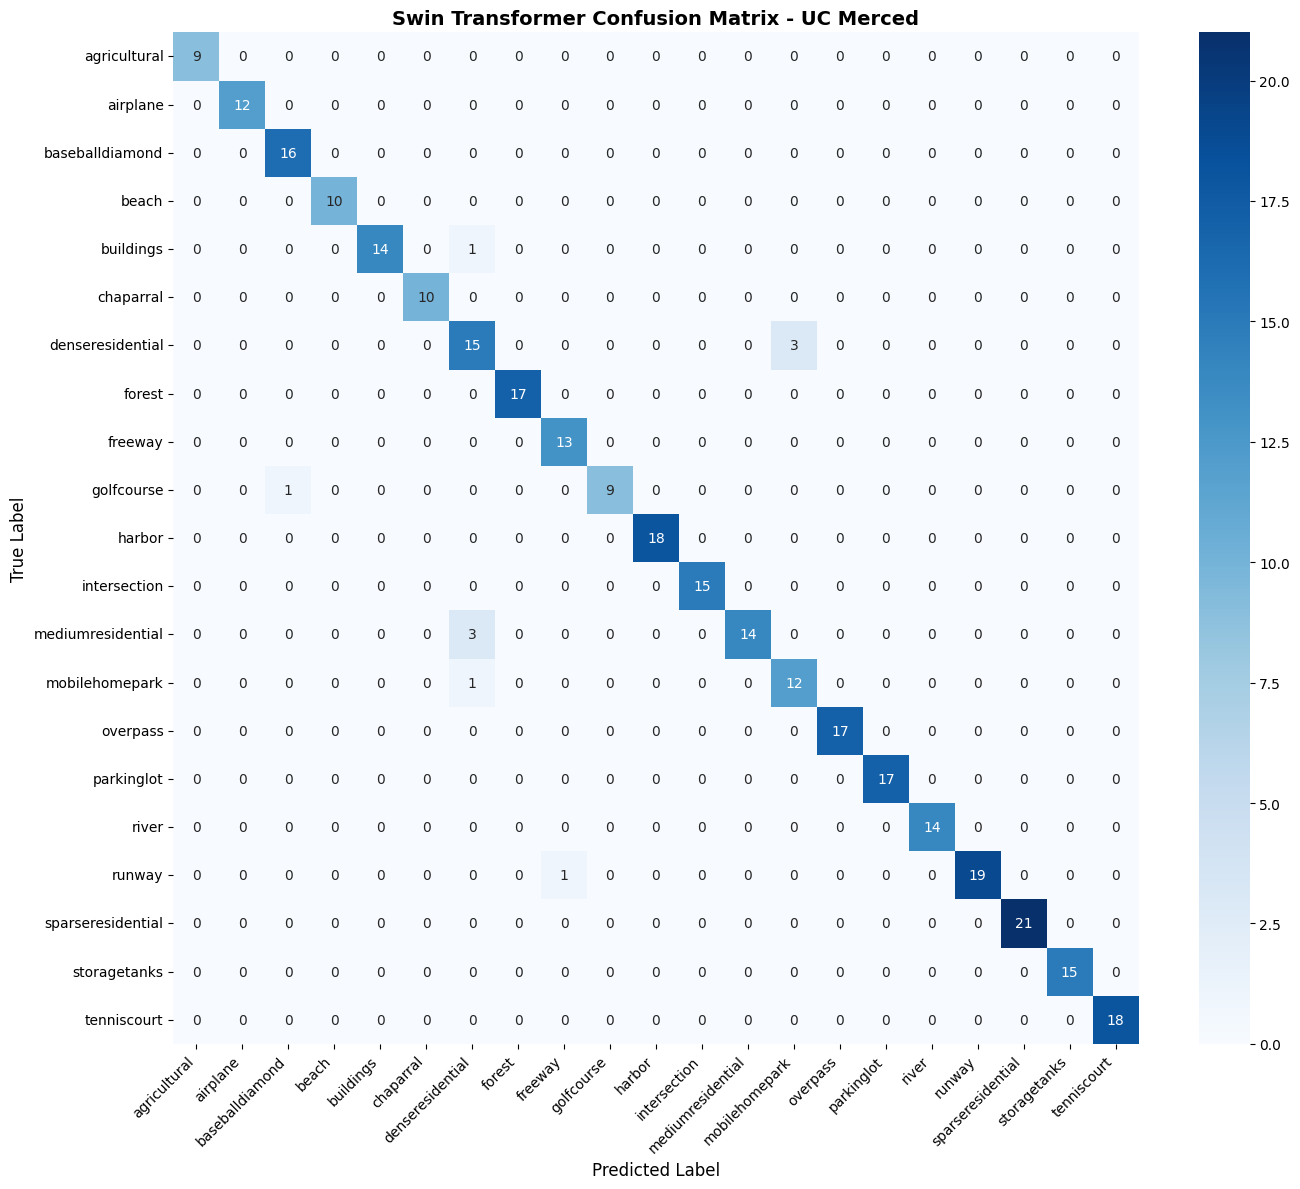

In [22]:
# ============================================================================
# EVALUATE SWIN TRANSFORMER ON UC MERCED - DETAILED METRICS
# ============================================================================

# Get predictions for confusion matrix
swin_ucm_model.eval()
all_preds_ucm_swin = []
all_labels_ucm_swin = []

with torch.no_grad():
    for images, labels, _ in test_loader_ucm:
        images = images.to(device)
        labels = labels.to(device)
        outputs = swin_ucm_model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds_ucm_swin.extend(preds)
        all_labels_ucm_swin.extend(labels.cpu().numpy())

all_preds_ucm_swin = np.array(all_preds_ucm_swin)
all_labels_ucm_swin = np.array(all_labels_ucm_swin)

# Calculate detailed metrics
precision_ucm_swin = precision_score(all_labels_ucm_swin, all_preds_ucm_swin, average='macro')
recall_ucm_swin = recall_score(all_labels_ucm_swin, all_preds_ucm_swin, average='macro')
f1_ucm_swin = swin_ucm_test_metrics['f1_macro']

print(f"\n📊 Swin Transformer UC Merced Detailed Metrics:")
print(f"   Accuracy: {swin_ucm_test_metrics['accuracy']:.4f}")
print(f"   Precision: {precision_ucm_swin:.4f}")
print(f"   Recall: {recall_ucm_swin:.4f}")
print(f"   F1-Score: {f1_ucm_swin:.4f}")

# Confusion Matrix
cm_ucm_swin = confusion_matrix(all_labels_ucm_swin, all_preds_ucm_swin)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_ucm_swin, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_ucm, yticklabels=class_names_ucm)
plt.title('Swin Transformer Confusion Matrix - UC Merced', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Store detailed metrics
ucmerced_results['Swin Transformer']['precision'] = precision_ucm_swin
ucmerced_results['Swin Transformer']['recall'] = recall_ucm_swin
ucmerced_results['Swin Transformer']['f1'] = f1_ucm_swin
ucmerced_results['Swin Transformer']['confusion_matrix'] = cm_ucm_swin



### Model 4: ResNet-18 on UC Merced



In [23]:
# ============================================================================
# CREATE RESNET-18 MODEL FOR UC MERCED
# ============================================================================

print("Creating ResNet-18 model for UC Merced...")
print("Pretrained on: ImageNet-1k")

# Load pretrained ResNet-18
resnet_ucm_model = models.resnet18(pretrained=True)

# Replace the final classification layer (21 classes for UC Merced)
num_features = resnet_ucm_model.fc.in_features
resnet_ucm_model.fc = nn.Linear(num_features, len(class_names_ucm))

# Count parameters
total_params_ucm_resnet, trainable_params_ucm_resnet = count_parameters(resnet_ucm_model)
print(f"\n✅ ResNet-18 Model Created for UC Merced!")
print(f"   Total parameters: {total_params_ucm_resnet:,}")
print(f"   Trainable parameters: {trainable_params_ucm_resnet:,}")
print(f"   Number of classes: {len(class_names_ucm)}")



Creating ResNet-18 model for UC Merced...
Pretrained on: ImageNet-1k

✅ ResNet-18 Model Created for UC Merced!
   Total parameters: 11,187,285
   Trainable parameters: 11,187,285
   Number of classes: 21


/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
# ============================================================================
# TRAIN RESNET-18 ON UC MERCED
# ============================================================================

resnet_ucm_model, resnet_ucm_history, resnet_ucm_test_metrics = train_model(
    model=resnet_ucm_model,
    model_name='ResNet-18-UCM',
    train_loader=train_loader_ucm,
    val_loader=val_loader_ucm,
    test_loader=test_loader_ucm,
    num_epochs=10,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
ucmerced_results['ResNet-18'] = {
    'history': resnet_ucm_history,
    'test_metrics': resnet_ucm_test_metrics,
    'test_accuracy': resnet_ucm_test_metrics['accuracy']
}




Training ResNet-18-UCM

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.76it/s, loss=0.671]



Train Loss: 1.6225 | Train Acc: 0.5912 | Train F1: 0.5786
Val Loss: 0.7168 | Val Acc: 0.8127 | Val F1: 0.8126
💾 Best model saved! (Val Loss: 0.7168)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.75it/s, loss=0.393]



Train Loss: 0.4407 | Train Acc: 0.8966 | Train F1: 0.8926
Val Loss: 0.3655 | Val Acc: 0.8889 | Val F1: 0.8901
💾 Best model saved! (Val Loss: 0.3655)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.0716 | Train Acc: 0.9816 | Train F1: 0.9811
Val Loss: 0.1768 | Val Acc: 0.9397 | Val F1: 0.9424

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.70it/s, loss=0.155]



Train Loss: 0.0595 | Train Acc: 0.9850 | Train F1: 0.9849
Val Loss: 0.1735 | Val Acc: 0.9302 | Val F1: 0.9316

Training completed in 10.12 minutes

Evaluating ResNet-18-UCM on test set...


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.71it/s, loss=0.103]


📊 Test Results for ResNet-18-UCM:
   Loss: 0.1175
   Accuracy: 0.9683
   F1-Macro: 0.9687
   F1-Weighted: 0.9683
   Balanced Accuracy: 0.9684



📊 ResNet-18 UC Merced Detailed Metrics:
   Accuracy: 0.9683
   Precision: 0.9733
   Recall: 0.9684
   F1-Score: 0.9687


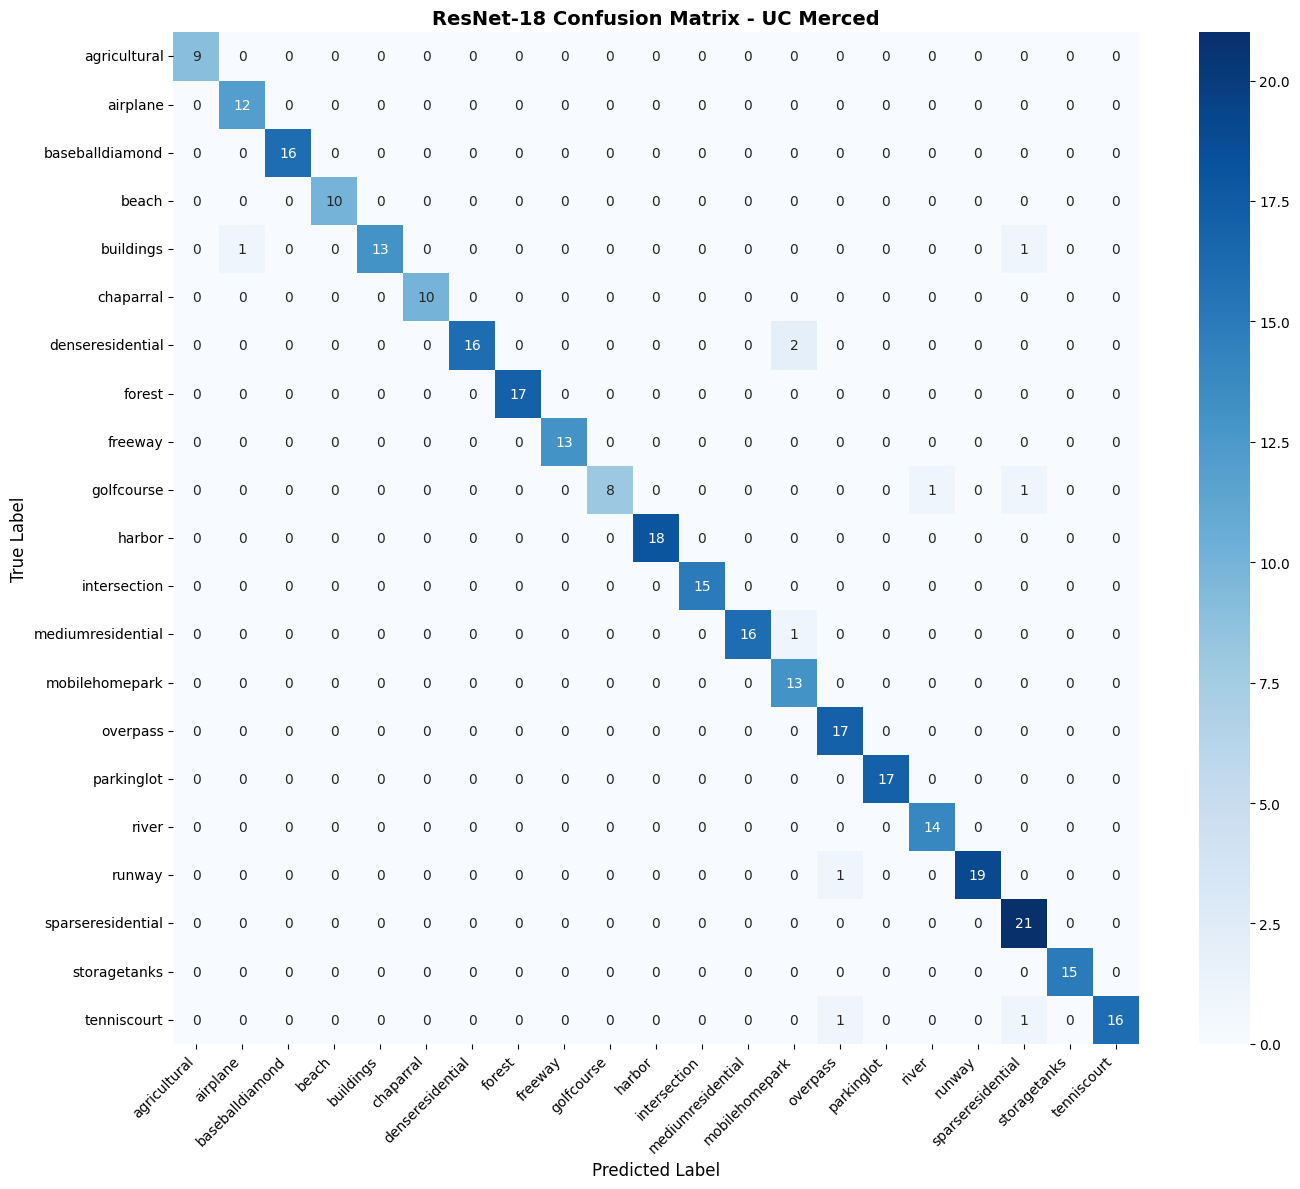

In [26]:
# ============================================================================
# EVALUATE RESNET-18 ON UC MERCED - DETAILED METRICS
# ============================================================================

# Get predictions for confusion matrix
resnet_ucm_model.eval()
all_preds_ucm_resnet = []
all_labels_ucm_resnet = []

with torch.no_grad():
    for images, labels, _ in test_loader_ucm:
        images = images.to(device)
        labels = labels.to(device)
        outputs = resnet_ucm_model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds_ucm_resnet.extend(preds)
        all_labels_ucm_resnet.extend(labels.cpu().numpy())

all_preds_ucm_resnet = np.array(all_preds_ucm_resnet)
all_labels_ucm_resnet = np.array(all_labels_ucm_resnet)

# Calculate detailed metrics
precision_ucm_resnet = precision_score(all_labels_ucm_resnet, all_preds_ucm_resnet, average='macro')
recall_ucm_resnet = recall_score(all_labels_ucm_resnet, all_preds_ucm_resnet, average='macro')
f1_ucm_resnet = resnet_ucm_test_metrics['f1_macro']

print(f"\n📊 ResNet-18 UC Merced Detailed Metrics:")
print(f"   Accuracy: {resnet_ucm_test_metrics['accuracy']:.4f}")
print(f"   Precision: {precision_ucm_resnet:.4f}")
print(f"   Recall: {recall_ucm_resnet:.4f}")
print(f"   F1-Score: {f1_ucm_resnet:.4f}")

# Confusion Matrix
cm_ucm_resnet = confusion_matrix(all_labels_ucm_resnet, all_preds_ucm_resnet)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_ucm_resnet, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_ucm, yticklabels=class_names_ucm)
plt.title('ResNet-18 Confusion Matrix - UC Merced', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Store detailed metrics
ucmerced_results['ResNet-18']['precision'] = precision_ucm_resnet
ucmerced_results['ResNet-18']['recall'] = recall_ucm_resnet
ucmerced_results['ResNet-18']['f1'] = f1_ucm_resnet
ucmerced_results['ResNet-18']['confusion_matrix'] = cm_ucm_resnet



### Model 5: Simple CNN on UC Merced



In [27]:
# ============================================================================
# CREATE SIMPLE CNN MODEL FOR UC MERCED
# ============================================================================

class SimpleCNNUCM(nn.Module):
    """Simple CNN architecture for UC Merced LULC classification"""
    def __init__(self, num_classes=21):
        super(SimpleCNNUCM, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        # After 3 pooling operations: 128/2/2/2 = 16, so 16*16*128 = 32768
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Conv block 1
        x = self.pool(torch.relu(self.conv1(x)))
        
        # Conv block 2
        x = self.pool(torch.relu(self.conv2(x)))
        
        # Conv block 3
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(-1, 128 * 16 * 16)
        
        # Fully connected layers
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

print("Creating Simple CNN model for UC Merced (from scratch)...")
simple_cnn_ucm_model = SimpleCNNUCM(num_classes=len(class_names_ucm))

# Count parameters
total_params_ucm_cnn, trainable_params_ucm_cnn = count_parameters(simple_cnn_ucm_model)
print(f"\n✅ Simple CNN Model Created for UC Merced!")
print(f"   Total parameters: {total_params_ucm_cnn:,}")
print(f"   Trainable parameters: {trainable_params_ucm_cnn:,}")
print(f"   Number of classes: {len(class_names_ucm)}")
print(f"   Model type: FROM SCRATCH (no pretrained weights)")



Creating Simple CNN model for UC Merced (from scratch)...

✅ Simple CNN Model Created for UC Merced!
   Total parameters: 16,881,749
   Trainable parameters: 16,881,749
   Number of classes: 21
   Model type: FROM SCRATCH (no pretrained weights)


In [28]:
# ============================================================================
# TRAIN SIMPLE CNN ON UC MERCED
# ============================================================================

# Use higher learning rate for from-scratch training
simple_cnn_ucm_model, simple_cnn_ucm_history, simple_cnn_ucm_test_metrics = train_model(
    model=simple_cnn_ucm_model,
    model_name='Simple CNN-UCM',
    train_loader=train_loader_ucm,
    val_loader=val_loader_ucm,
    test_loader=test_loader_ucm,
    num_epochs=15,  # More epochs for from-scratch training
    learning_rate=0.001,  # Higher LR for from-scratch
    early_stopping_patience=3
)

# Store results
ucmerced_results['Simple CNN'] = {
    'history': simple_cnn_ucm_history,
    'test_metrics': simple_cnn_ucm_test_metrics,
    'test_accuracy': simple_cnn_ucm_test_metrics['accuracy']
}




Training Simple CNN-UCM

Epoch 1/15
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:01<00:00,  5.28it/s, loss=2.8]



Train Loss: 2.9754 | Train Acc: 0.1061 | Train F1: 0.0699
Val Loss: 2.6776 | Val Acc: 0.1460 | Val F1: 0.0847
💾 Best model saved! (Val Loss: 2.6776)

Epoch 2/15
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:01<00:00,  5.24it/s, loss=2.4]



Train Loss: 2.5138 | Train Acc: 0.2259 | Train F1: 0.1775
Val Loss: 2.3317 | Val Acc: 0.2921 | Val F1: 0.2647
💾 Best model saved! (Val Loss: 2.3317)

Epoch 3/15
------------------------------------------------------------


...


Train Loss: 0.9586 | Train Acc: 0.6837 | Train F1: 0.6762
Val Loss: 0.9514 | Val Acc: 0.6857 | Val F1: 0.6891
💾 Best model saved! (Val Loss: 0.9514)

Epoch 15/15
------------------------------------------------------------


Validation: 100%|██████████| 10/10 [00:01<00:00,  5.31it/s, loss=0.684]



Train Loss: 0.7779 | Train Acc: 0.7422 | Train F1: 0.7370
Val Loss: 0.9286 | Val Acc: 0.6952 | Val F1: 0.6803
💾 Best model saved! (Val Loss: 0.9286)

Training completed in 5.44 minutes

Evaluating Simple CNN-UCM on test set...


Validation: 100%|██████████| 10/10 [00:02<00:00,  4.87it/s, loss=0.911]


📊 Test Results for Simple CNN-UCM:
   Loss: 0.8595
   Accuracy: 0.7206
   F1-Macro: 0.7203
   F1-Weighted: 0.7113
   Balanced Accuracy: 0.7377



📊 Simple CNN UC Merced Detailed Metrics:
   Accuracy: 0.7206
   Precision: 0.7498
   Recall: 0.7377
   F1-Score: 0.7203


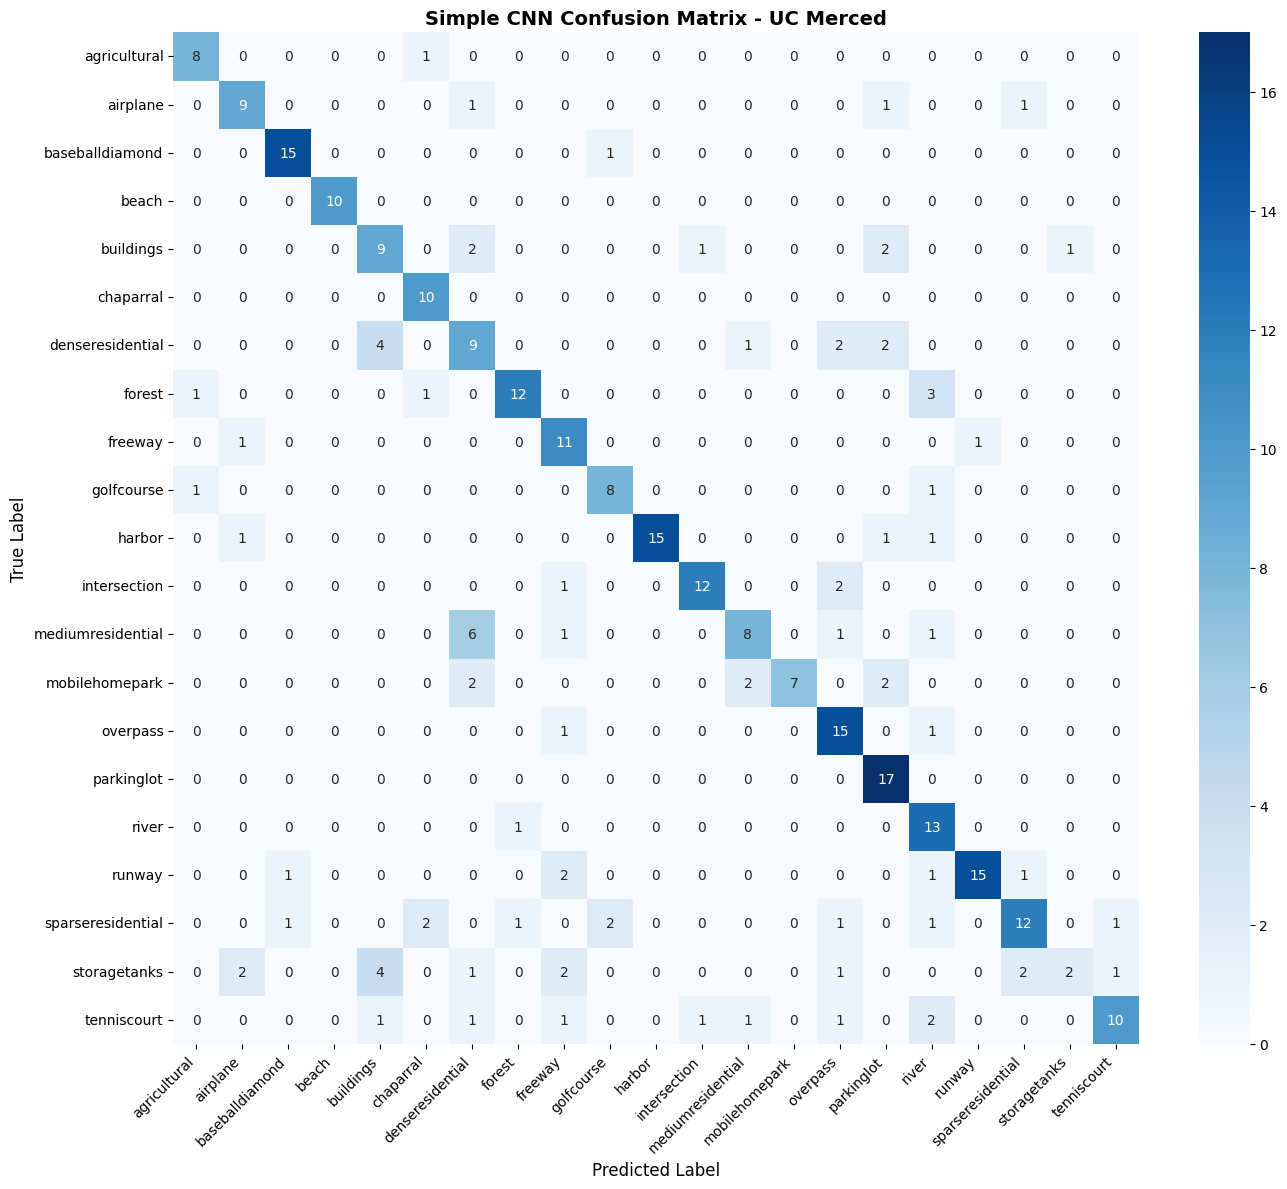

In [29]:
# ============================================================================
# EVALUATE SIMPLE CNN ON UC MERCED - DETAILED METRICS
# ============================================================================

# Get predictions for confusion matrix
simple_cnn_ucm_model.eval()
all_preds_ucm_cnn = []
all_labels_ucm_cnn = []

with torch.no_grad():
    for images, labels, _ in test_loader_ucm:
        images = images.to(device)
        labels = labels.to(device)
        outputs = simple_cnn_ucm_model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds_ucm_cnn.extend(preds)
        all_labels_ucm_cnn.extend(labels.cpu().numpy())

all_preds_ucm_cnn = np.array(all_preds_ucm_cnn)
all_labels_ucm_cnn = np.array(all_labels_ucm_cnn)

# Calculate detailed metrics
precision_ucm_cnn = precision_score(all_labels_ucm_cnn, all_preds_ucm_cnn, average='macro')
recall_ucm_cnn = recall_score(all_labels_ucm_cnn, all_preds_ucm_cnn, average='macro')
f1_ucm_cnn = simple_cnn_ucm_test_metrics['f1_macro']

print(f"\n📊 Simple CNN UC Merced Detailed Metrics:")
print(f"   Accuracy: {simple_cnn_ucm_test_metrics['accuracy']:.4f}")
print(f"   Precision: {precision_ucm_cnn:.4f}")
print(f"   Recall: {recall_ucm_cnn:.4f}")
print(f"   F1-Score: {f1_ucm_cnn:.4f}")

# Confusion Matrix
cm_ucm_cnn = confusion_matrix(all_labels_ucm_cnn, all_preds_ucm_cnn)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_ucm_cnn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_ucm, yticklabels=class_names_ucm)
plt.title('Simple CNN Confusion Matrix - UC Merced', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Store detailed metrics
ucmerced_results['Simple CNN']['precision'] = precision_ucm_cnn
ucmerced_results['Simple CNN']['recall'] = recall_ucm_cnn
ucmerced_results['Simple CNN']['f1'] = f1_ucm_cnn
ucmerced_results['Simple CNN']['confusion_matrix'] = cm_ucm_cnn



## Manually Insert EuroSAT Results and Compare with UC Merced

**Note:** The following EuroSAT results are manually inserted from the test set performance and should NOT be recomputed.



In [53]:
# ============================================================================
# MANUALLY INSERT EUROSAT RESULTS (FROM TEST SET PERFORMANCE)
# ============================================================================

# Import required metrics
from sklearn.metrics import precision_score, recall_score

# These results are MANUALLY INSERTED from EuroSAT Test Set Performance
# Values from: Test Set Performance (sorted by Accuracy)
eurosat_results = {
    'Swin Transformer': {
        'accuracy': 0.982593,
        'f1_macro': 0.981914,
        'f1_weighted': 0.982632,
        'balanced_accuracy': 0.982033,
      
    },
    'DenseNet-121': {
        'accuracy': 0.981852,
        'f1_macro': 0.981509,
        'f1_weighted': 0.981859,
        'balanced_accuracy': 0.980333,
      
    },
    'ResNet-18': {
        'accuracy': 0.979259,
        'f1_macro': 0.978609,
        'f1_weighted': 0.979276,
        'balanced_accuracy': 0.979033,
        'precision': None,
        'recall': None
    },
    'ViT': {
        'accuracy': 0.970000,
        'f1_macro': 0.968809,
        'f1_weighted': 0.970047,
        'balanced_accuracy': 0.969067,
      
    },
    'EfficientNet-B0': {
        'accuracy': 0.958148,
        'f1_macro': 0.957091,
        'f1_weighted': 0.958467,
        'balanced_accuracy': 0.958133,
        
    },
    'Simple CNN': {
        'accuracy': 0.888519,
        'f1_macro': 0.884329,
        'f1_weighted': 0.887547,
        'balanced_accuracy': 0.885800,
       
    }
}

# Try to calculate precision and recall from models if available
if 'all_model_results' in globals() and 'test_loader' in globals():
    model_keys_mapping = {
        'Swin Transformer': 'Swin Transformer',
        'DenseNet-121': 'DenseNet-121',
        'ResNet-18': 'ResNet-18',
        'ViT': 'ViT',
        'EfficientNet-B0': 'EfficientNet-B0',
        'Simple CNN': 'Simple CNN'
    }
    


## UC Merced Models Comparison

This section compares all models trained on the UC Merced dataset to identify the best performing model.



In [41]:
# ============================================================================
# UC MERCED MODELS COMPARISON TABLE
# ============================================================================

# Create comparison dataframe for UC Merced models only
ucm_comparison_data = []

# Add all UC Merced models
ucm_model_list = ['Swin Transformer', 'DenseNet-121', 'ResNet-18', 'ViT', 'Simple CNN']
for model_name in ucm_model_list:
    if model_name in ucmerced_results:
        ucm_comparison_data.append({
            'Model': model_name,
            'Accuracy': ucmerced_results[model_name]['test_accuracy'],
            'Precision': ucmerced_results[model_name]['precision'],
            'Recall': ucmerced_results[model_name]['recall'],
            'F1-Score': ucmerced_results[model_name]['f1']
        })

ucm_comparison_df = pd.DataFrame(ucm_comparison_data)
ucm_comparison_df = ucm_comparison_df.sort_values('Accuracy', ascending=False)

print("="*80)
print("UC MERCED DATASET - MODEL COMPARISON")
print("="*80)
print("\n📊 Performance Comparison (sorted by Accuracy):")
print(ucm_comparison_df.to_string(index=False))

# Find best model
if len(ucm_comparison_df) > 0:
    best_ucm_model = ucm_comparison_df.iloc[0]
    print(f"\n🏆 Best Model on UC Merced: {best_ucm_model['Model']}")
    print(f"   Accuracy: {best_ucm_model['Accuracy']:.4f}")
    print(f"   F1-Score: {best_ucm_model['F1-Score']:.4f}")



UC MERCED DATASET - MODEL COMPARISON

📊 Performance Comparison (sorted by Accuracy):
           Model  Accuracy  Precision   Recall  F1-Score
    DenseNet-121  0.980952   0.981121 0.983707  0.981442
Swin Transformer  0.968254   0.972369 0.969680  0.969988
       ResNet-18  0.968254   0.973269 0.968363  0.968748
             ViT  0.942857   0.949431 0.948790  0.945203
      Simple CNN  0.720635   0.749836 0.737717  0.720314

🏆 Best Model on UC Merced: DenseNet-121
   Accuracy: 0.9810
   F1-Score: 0.9814


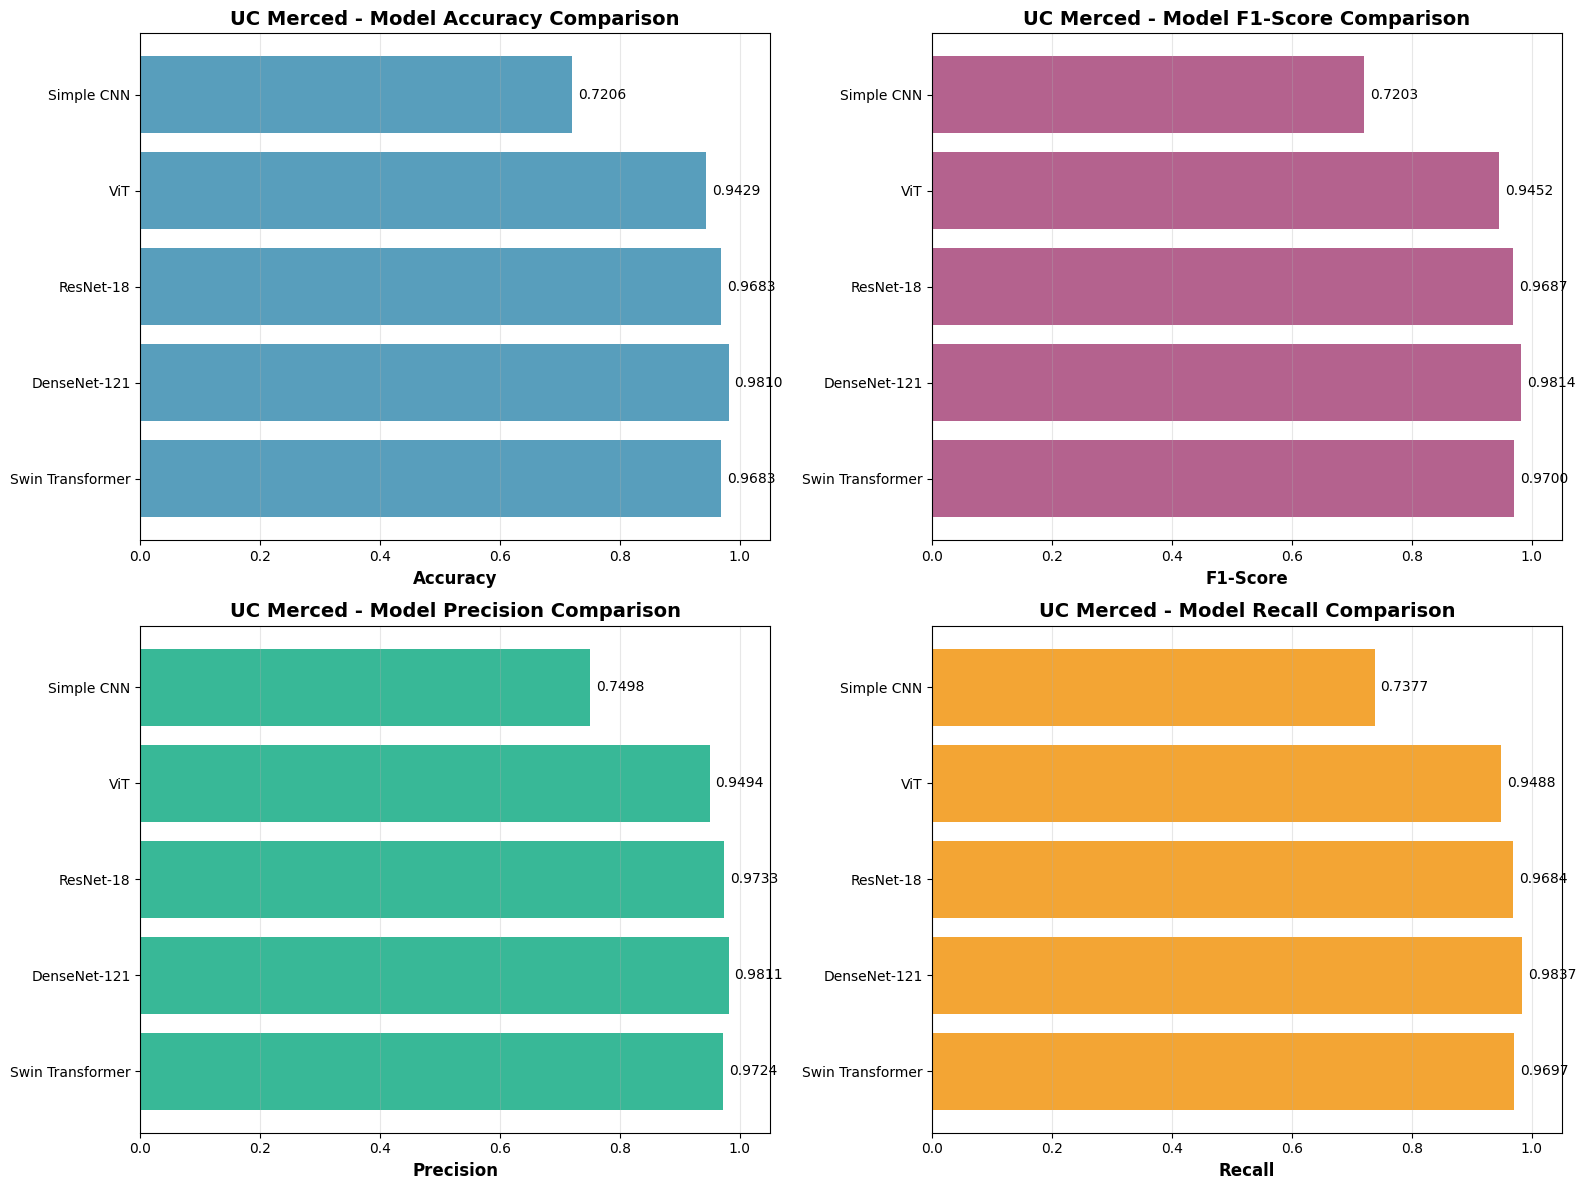

In [38]:
# ============================================================================
# UC MERCED MODELS VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data
ucm_models = []
ucm_acc = []
ucm_prec = []
ucm_rec = []
ucm_f1 = []

for model_name in ['Swin Transformer', 'DenseNet-121', 'ResNet-18', 'ViT', 'Simple CNN']:
    if model_name in ucmerced_results:
        ucm_models.append(model_name)
        ucm_acc.append(ucmerced_results[model_name]['test_accuracy'])
        ucm_prec.append(ucmerced_results[model_name]['precision'])
        ucm_rec.append(ucmerced_results[model_name]['recall'])
        ucm_f1.append(ucmerced_results[model_name]['f1'])

# Plot 1: Accuracy Comparison
axes[0, 0].barh(ucm_models, ucm_acc, alpha=0.8, color='#2E86AB')
axes[0, 0].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_title('UC Merced - Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0, 1.05])
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(ucm_acc):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Plot 2: F1-Score Comparison
axes[0, 1].barh(ucm_models, ucm_f1, alpha=0.8, color='#A23B72')
axes[0, 1].set_xlabel('F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('UC Merced - Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 1.05])
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(ucm_f1):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Plot 3: Precision Comparison
axes[1, 0].barh(ucm_models, ucm_prec, alpha=0.8, color='#06A77D')
axes[1, 0].set_xlabel('Precision', fontsize=12, fontweight='bold')
axes[1, 0].set_title('UC Merced - Model Precision Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim([0, 1.05])
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(ucm_prec):
    axes[1, 0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Plot 4: Recall Comparison
axes[1, 1].barh(ucm_models, ucm_rec, alpha=0.8, color='#F18F01')
axes[1, 1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1, 1].set_title('UC Merced - Model Recall Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim([0, 1.05])
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(ucm_rec):
    axes[1, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()



In [44]:
import pandas as pd

# ============================================================================
# COMPARISON TABLE: EUROSAT vs UC MERCED (SIDE-BY-SIDE)
# ============================================================================

comparison_data = []

# -----------------------------
# Add EuroSAT results
# -----------------------------
eurosat_model_list = [
    'Swin Transformer',
    'DenseNet-121',
    'ResNet-18',
    'ViT',
    'Simple CNN'
]

for model_name in eurosat_model_list:
    if model_name in eurosat_results:
        comparison_data.append({
            'Model': model_name,
            'Dataset': 'EuroSAT',
            'Accuracy': eurosat_results[model_name]['accuracy'],
            'F1-Macro': eurosat_results[model_name]['f1_macro'],
            'Precision': eurosat_results[model_name]['precision']
                         if eurosat_results[model_name]['precision'] is not None else 0.0,
            'Recall': eurosat_results[model_name]['recall']
                      if eurosat_results[model_name]['recall'] is not None else 0.0
        })

# -----------------------------
# Add UC Merced results
# -----------------------------
ucm_model_list = [
    'Swin Transformer',
    'DenseNet-121',
    'ResNet-18',
    'ViT',
    'Simple CNN'
]

for model_name in ucm_model_list:
    if model_name in ucmerced_results:
        comparison_data.append({
            'Model': model_name,
            'Dataset': 'UC Merced',
            'Accuracy': ucmerced_results[model_name]['test_accuracy'],
            'F1-Macro': ucmerced_results[model_name]['f1'],
            'Precision': ucmerced_results[model_name]['precision'],
            'Recall': ucmerced_results[model_name]['recall']
        })

# -----------------------------
# Create DataFrame
# -----------------------------
comparison_df = pd.DataFrame(comparison_data)

# -----------------------------
# Pivot for side-by-side view
# -----------------------------
side_by_side_df = comparison_df.pivot(
    index='Model',
    columns='Dataset',
    values=['Accuracy', 'F1-Macro', 'Precision', 'Recall']
)

# Flatten column names
side_by_side_df.columns = [
    f"{metric}_{dataset}"
    for metric, dataset in side_by_side_df.columns
]

side_by_side_df = side_by_side_df.reset_index()

# -----------------------------
# Display results
# -----------------------------
print("=" * 110)
print(" EUROSAT vs UC MERCED")
print("=" * 110)
print(side_by_side_df.round(4).to_string(index=False))

 EUROSAT vs UC MERCED
           Model  Accuracy_EuroSAT  Accuracy_UC Merced  F1-Macro_EuroSAT  F1-Macro_UC Merced  Precision_EuroSAT  Precision_UC Merced  Recall_EuroSAT  Recall_UC Merced
    DenseNet-121            0.9819              0.9810            0.9815              0.9814                0.0               0.9811             0.0            0.9837
       ResNet-18            0.9793              0.9683            0.9786              0.9687                0.0               0.9733             0.0            0.9684
      Simple CNN            0.8885              0.7206            0.8843              0.7203                0.0               0.7498             0.0            0.7377
Swin Transformer            0.9826              0.9683            0.9819              0.9700                0.0               0.9724             0.0            0.9697
             ViT            0.9700              0.9429            0.9688              0.9452                0.0               0.9494           

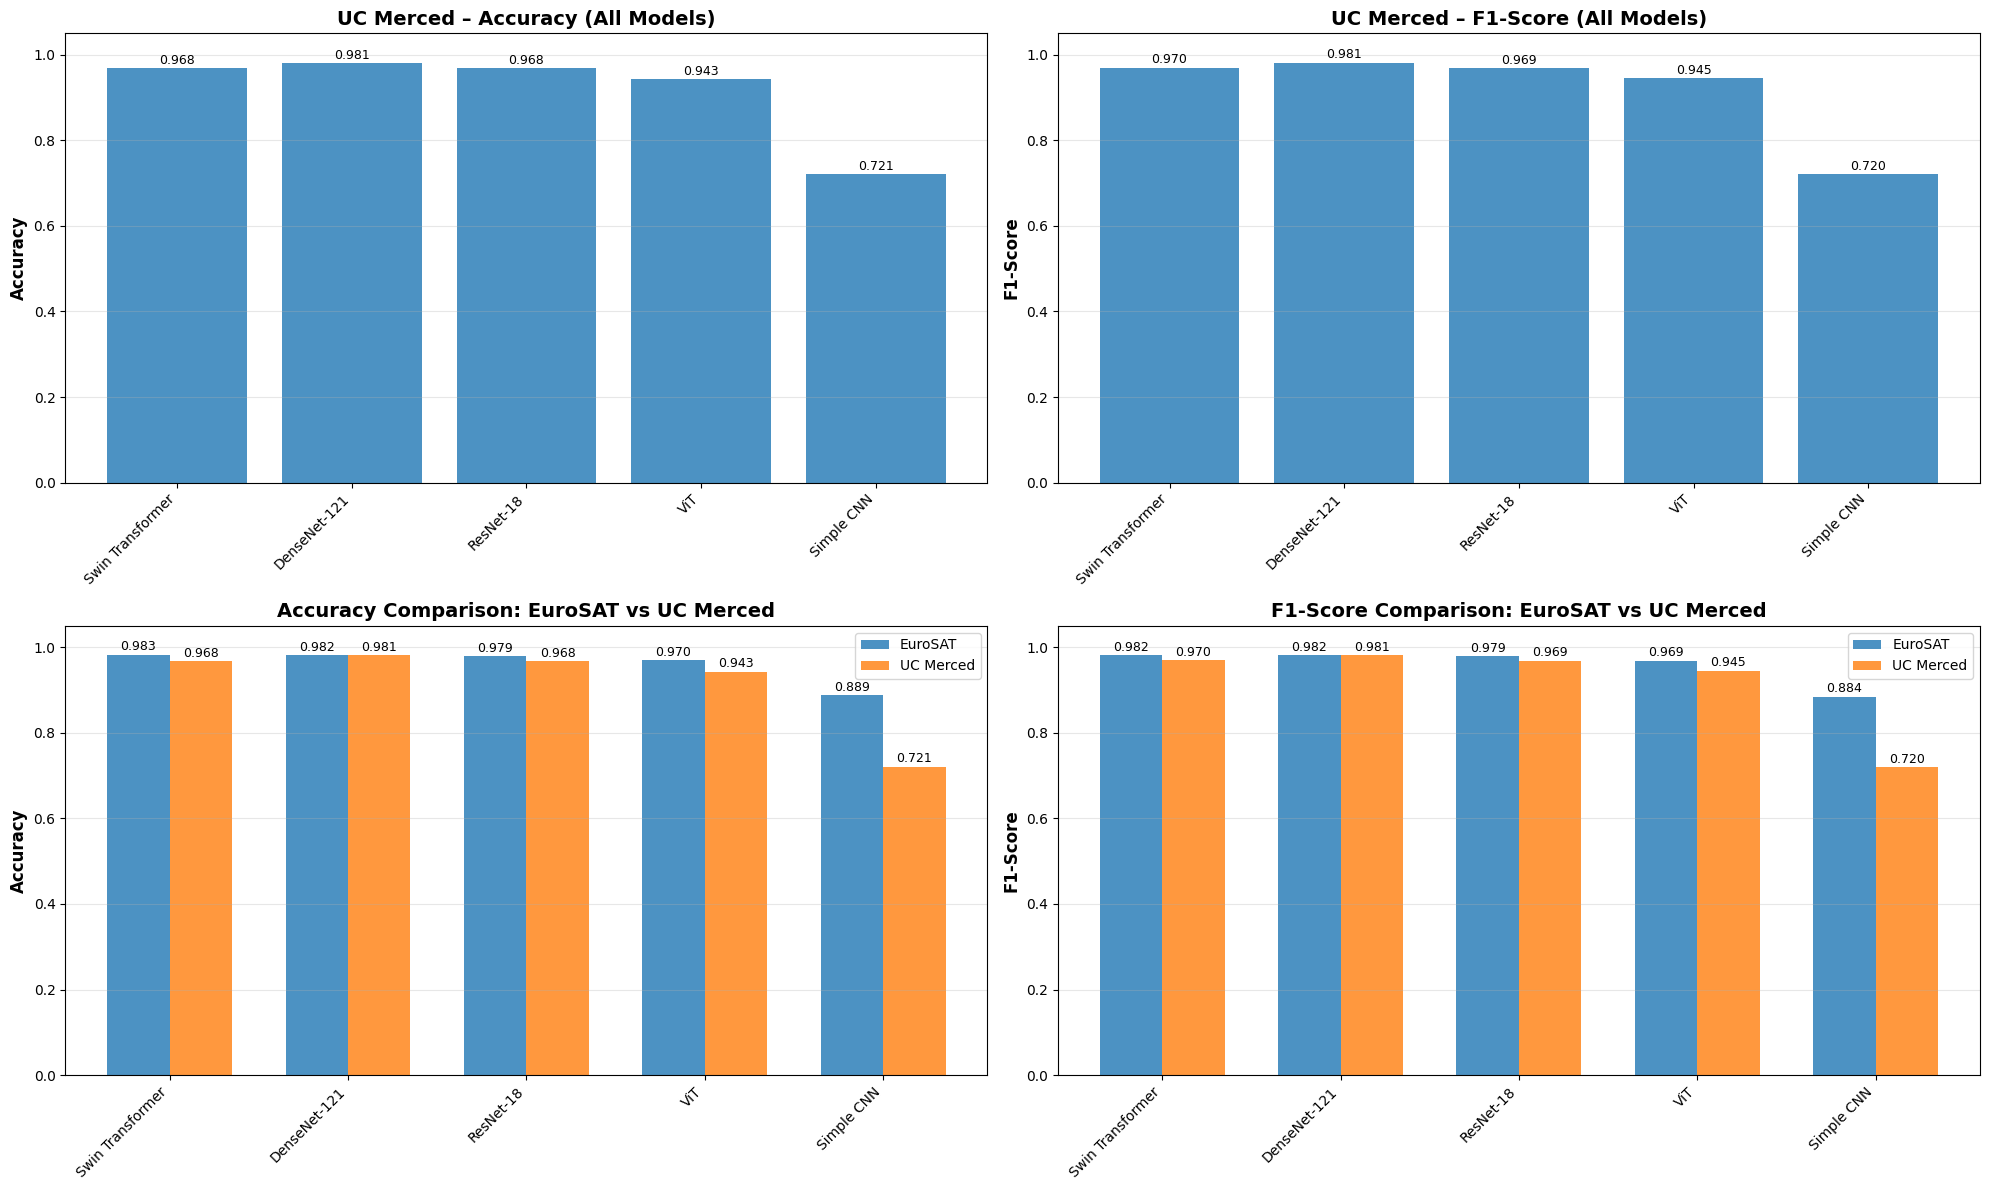

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# VISUALIZATION: EUROSAT vs UC MERCED COMPARISON PLOTS (FULL)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# --------------------------------------------------------------------------
# UC MERCED – ALL MODELS (Accuracy & F1)
# --------------------------------------------------------------------------
ucm_models = []
ucm_acc = []
ucm_f1 = []

for model_name in ['Swin Transformer', 'DenseNet-121', 'ResNet-18', 'ViT', 'Simple CNN']:
    if model_name in ucmerced_results:
        ucm_models.append(model_name)
        ucm_acc.append(ucmerced_results[model_name]['test_accuracy'])
        ucm_f1.append(ucmerced_results[model_name]['f1'])

x_ucm = np.arange(len(ucm_models))

# ---------------- Plot 1: UC Merced Accuracy ----------------
axes[0, 0].bar(x_ucm, ucm_acc, alpha=0.8)
axes[0, 0].set_title('UC Merced – Accuracy (All Models)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_ucm)
axes[0, 0].set_xticklabels(ucm_models, rotation=45, ha='right')
axes[0, 0].set_ylim([0, 1.05])
axes[0, 0].grid(axis='y', alpha=0.3)

for i, acc in enumerate(ucm_acc):
    axes[0, 0].text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=9)

# ---------------- Plot 2: UC Merced F1-Score ----------------
axes[0, 1].bar(x_ucm, ucm_f1, alpha=0.8)
axes[0, 1].set_title('UC Merced – F1-Score (All Models)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_ucm)
axes[0, 1].set_xticklabels(ucm_models, rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1.05])
axes[0, 1].grid(axis='y', alpha=0.3)

for i, f1 in enumerate(ucm_f1):
    axes[0, 1].text(i, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=9)

# --------------------------------------------------------------------------
# EUROSAT vs UC MERCED (ONLY COMMON MODELS)
# --------------------------------------------------------------------------
common_models = ucm_models
x = np.arange(len(common_models))
width = 0.35

eurosat_acc_ucm = [eurosat_results[m]['accuracy'] for m in common_models]
eurosat_f1_ucm = [eurosat_results[m]['f1_macro'] for m in common_models]

# ---------------- Plot 3: Accuracy Comparison ----------------
axes[1, 0].bar(x - width/2, eurosat_acc_ucm, width, label='EuroSAT', alpha=0.8)
axes[1, 0].bar(x + width/2, ucm_acc, width, label='UC Merced', alpha=0.8)

axes[1, 0].set_title('Accuracy Comparison: EuroSAT vs UC Merced',
                     fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(common_models, rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

for i, (euro, ucm) in enumerate(zip(eurosat_acc_ucm, ucm_acc)):
    axes[1, 0].text(i - width/2, euro + 0.01, f'{euro:.3f}', ha='center', fontsize=9)
    axes[1, 0].text(i + width/2, ucm + 0.01, f'{ucm:.3f}', ha='center', fontsize=9)

# ---------------- Plot 4: F1-Score Comparison ----------------
axes[1, 1].bar(x - width/2, eurosat_f1_ucm, width, label='EuroSAT', alpha=0.8)
axes[1, 1].bar(x + width/2, ucm_f1, width, label='UC Merced', alpha=0.8)

axes[1, 1].set_title('F1-Score Comparison: EuroSAT vs UC Merced',
                     fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(common_models, rotation=45, ha='right')
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

for i, (euro, ucm) in enumerate(zip(eurosat_f1_ucm, ucm_f1)):
    axes[1, 1].text(i - width/2, euro + 0.01, f'{euro:.3f}', ha='center', fontsize=9)
    axes[1, 1].text(i + width/2, ucm + 0.01, f'{ucm:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()